# Training a Computer-Using Agent (CUA) for GUI Task Automation — Group 5

**Authors:** William Gao, Jamie Linsdell, Tim Zhang

## 0. Setup

In [14]:
# Install dependencies
# transformers >=4.45.0 required for both Florence-2 and Qwen2-VL
!pip install -q datasets huggingface_hub matplotlib seaborn numpy pandas timm einops
!pip install -q 'transformers>=4.45.0' 'accelerate>=0.34.0' qwen-vl-utils

  Using cached flash_attn-2.8.3.tar.gz (8.4 MB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for flash-attn
  Running setup.py clean for flash-attn
Failed to build flash-attn
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (flash-attn)


In [3]:
import os
import shutil
import time
import zipfile
import random
import json
import io
import textwrap
from PIL import Image
import matplotlib.pyplot as plt
from datasets import load_dataset

In [5]:
# MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1. Data Loading

Loading our UGround subsample from Google Drive. On first run the ZIP is extracted into Drive (~5–10 min); subsequent sessions detect the folder and skip extraction entirely.

In [6]:
# OBTAIN ZIP FILE PATH

# For the path below to work as intended, in the Google Drive web UI, go to "Shared with me",
# right-click the "Too CUA for School" folder → Organise → Add shortcut → root of "My Drive".
NOTEBOOK_DIR = "/content/drive/MyDrive/Too CUA for School/MS3"
ZIP_FILENAME  = "jonathanliuground-v1-subsample.zip"

# Persistent extracted folder on Google Drive (created once, reused every session)
DRIVE_EXTRACT_DIR = os.path.join(NOTEBOOK_DIR, "jonathanliuground-v1-subsample")

# Local Colab session paths (fallback if not extracting to Drive)
LOCAL_ZIP_PATH = f"/content/{ZIP_FILENAME}"
EXTRACT_DIR    = "/content/jonathanliuground-v1-subsample"

# Full path to the ZIP on Drive
DRIVE_ZIP_PATH = os.path.join(NOTEBOOK_DIR, ZIP_FILENAME)

if os.path.isdir(DRIVE_EXTRACT_DIR):
    # Already extracted — no ZIP needed
    print(f"Extracted folder found: {DRIVE_EXTRACT_DIR}")
    print("Skipping ZIP check.")
else:
    # First time — need the ZIP to extract from
    assert os.path.isfile(DRIVE_ZIP_PATH), (
        f"ZIP not found at: {DRIVE_ZIP_PATH}\n"
        f"Either place the ZIP there or ensure the extracted folder exists at:\n"
        f"  {DRIVE_EXTRACT_DIR}"
    )
    zip_size_gb = os.path.getsize(DRIVE_ZIP_PATH) / (1024 ** 3)
    print(f"Found ZIP: {DRIVE_ZIP_PATH}  ({zip_size_gb:.2f} GB)")

Extracted folder found: /content/drive/MyDrive/Too CUA for School/MS3/jonathanliuground-v1-subsample
Skipping ZIP check.


In [7]:
# EXTRACT THE ZIP — persists to Google Drive so future sessions skip this step.
#
# First run  (~5–10 min): extracts parquet files into Drive.
# Future runs: Drive folder already exists → skips extraction entirely.

if os.path.isdir(DRIVE_EXTRACT_DIR):
    # Already extracted to Drive — use it directly (no copy/extract needed)
    EXTRACT_DIR = DRIVE_EXTRACT_DIR
    print(f"Found existing extraction in Drive: {DRIVE_EXTRACT_DIR}")
    print("Skipping copy + extraction.")

elif os.path.isdir(EXTRACT_DIR):
    # Already extracted locally this session
    print(f"Using local extraction at {EXTRACT_DIR}")

else:
    # First time: extract ZIP directly into Drive for persistence
    print(f"Extracting ZIP into Google Drive (one-time, ~5–10 min)...")
    print(f"Target: {DRIVE_EXTRACT_DIR}")
    start = time.time()
    with zipfile.ZipFile(DRIVE_ZIP_PATH, "r") as zf:
        zf.extractall(NOTEBOOK_DIR)
    elapsed = time.time() - start
    EXTRACT_DIR = DRIVE_EXTRACT_DIR
    print(f"Done in {elapsed:.0f}s. Future sessions will skip this step.")

# Walk extracted directory for parquet files
parquet_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith(".parquet"):
            parquet_files.append(os.path.join(root, f))

print(f"\nFound {len(parquet_files)} parquet files in {EXTRACT_DIR}")
subdirs = set(os.path.dirname(p).replace(EXTRACT_DIR, "").strip("/") for p in parquet_files)
subdirs = [s for s in subdirs if s]
if subdirs:
    print("Subfolders:")
    for s in sorted(subdirs):
        count = sum(1 for p in parquet_files if s in p)
        print(f"  {s}/  ({count} files)")

Found existing extraction in Drive: /content/drive/MyDrive/Too CUA for School/MS3/jonathanliuground-v1-subsample
Skipping copy + extraction.

Found 14 parquet files in /content/drive/MyDrive/Too CUA for School/MS3/jonathanliuground-v1-subsample
Subfolders:
  web_direct_150k_description_filtered/  (14 files)


In [25]:
# Delete local zip copy after extraction (if it exists) to save disk space
# if os.path.isfile(LOCAL_ZIP_PATH):
#   os.remove(LOCAL_ZIP_PATH)
#   print(f"Deleted {LOCAL_ZIP_PATH} to free disk space.")
# else:
#   print(f"No local copy of {LOCAL_ZIP_PATH} found.")

In [8]:
# LOAD PARQUET FILES AND COMBINE THEM INTO A DATASET
import glob as _glob

# Find all parquet files and filter out any 0-byte files
# (Drive sometimes creates empty placeholders during extraction)
all_pq = _glob.glob(f"{EXTRACT_DIR}/**/*.parquet", recursive=True)
valid_pq = [f for f in all_pq if os.path.getsize(f) > 0]

if len(all_pq) != len(valid_pq):
    print(f"Skipped {len(all_pq) - len(valid_pq)} empty/corrupt parquet files.")

print(f"Loading {len(valid_pq)} valid parquet files...")

ds = load_dataset(
    "parquet",
    data_files=valid_pq,
    split="train"
)

print(f"Dataset loaded: {len(ds):,} rows")
print(f"Columns: {ds.column_names}")
print(ds)

Skipped 1 empty/corrupt parquet files.
Loading 13 valid parquet files...


Generating train split: 0 examples [00:00, ? examples/s]

Dataset loaded: 3,570 rows
Columns: ['width', 'height', 'conversations', 'image']
Dataset({
    features: ['width', 'height', 'conversations', 'image'],
    num_rows: 3570
})


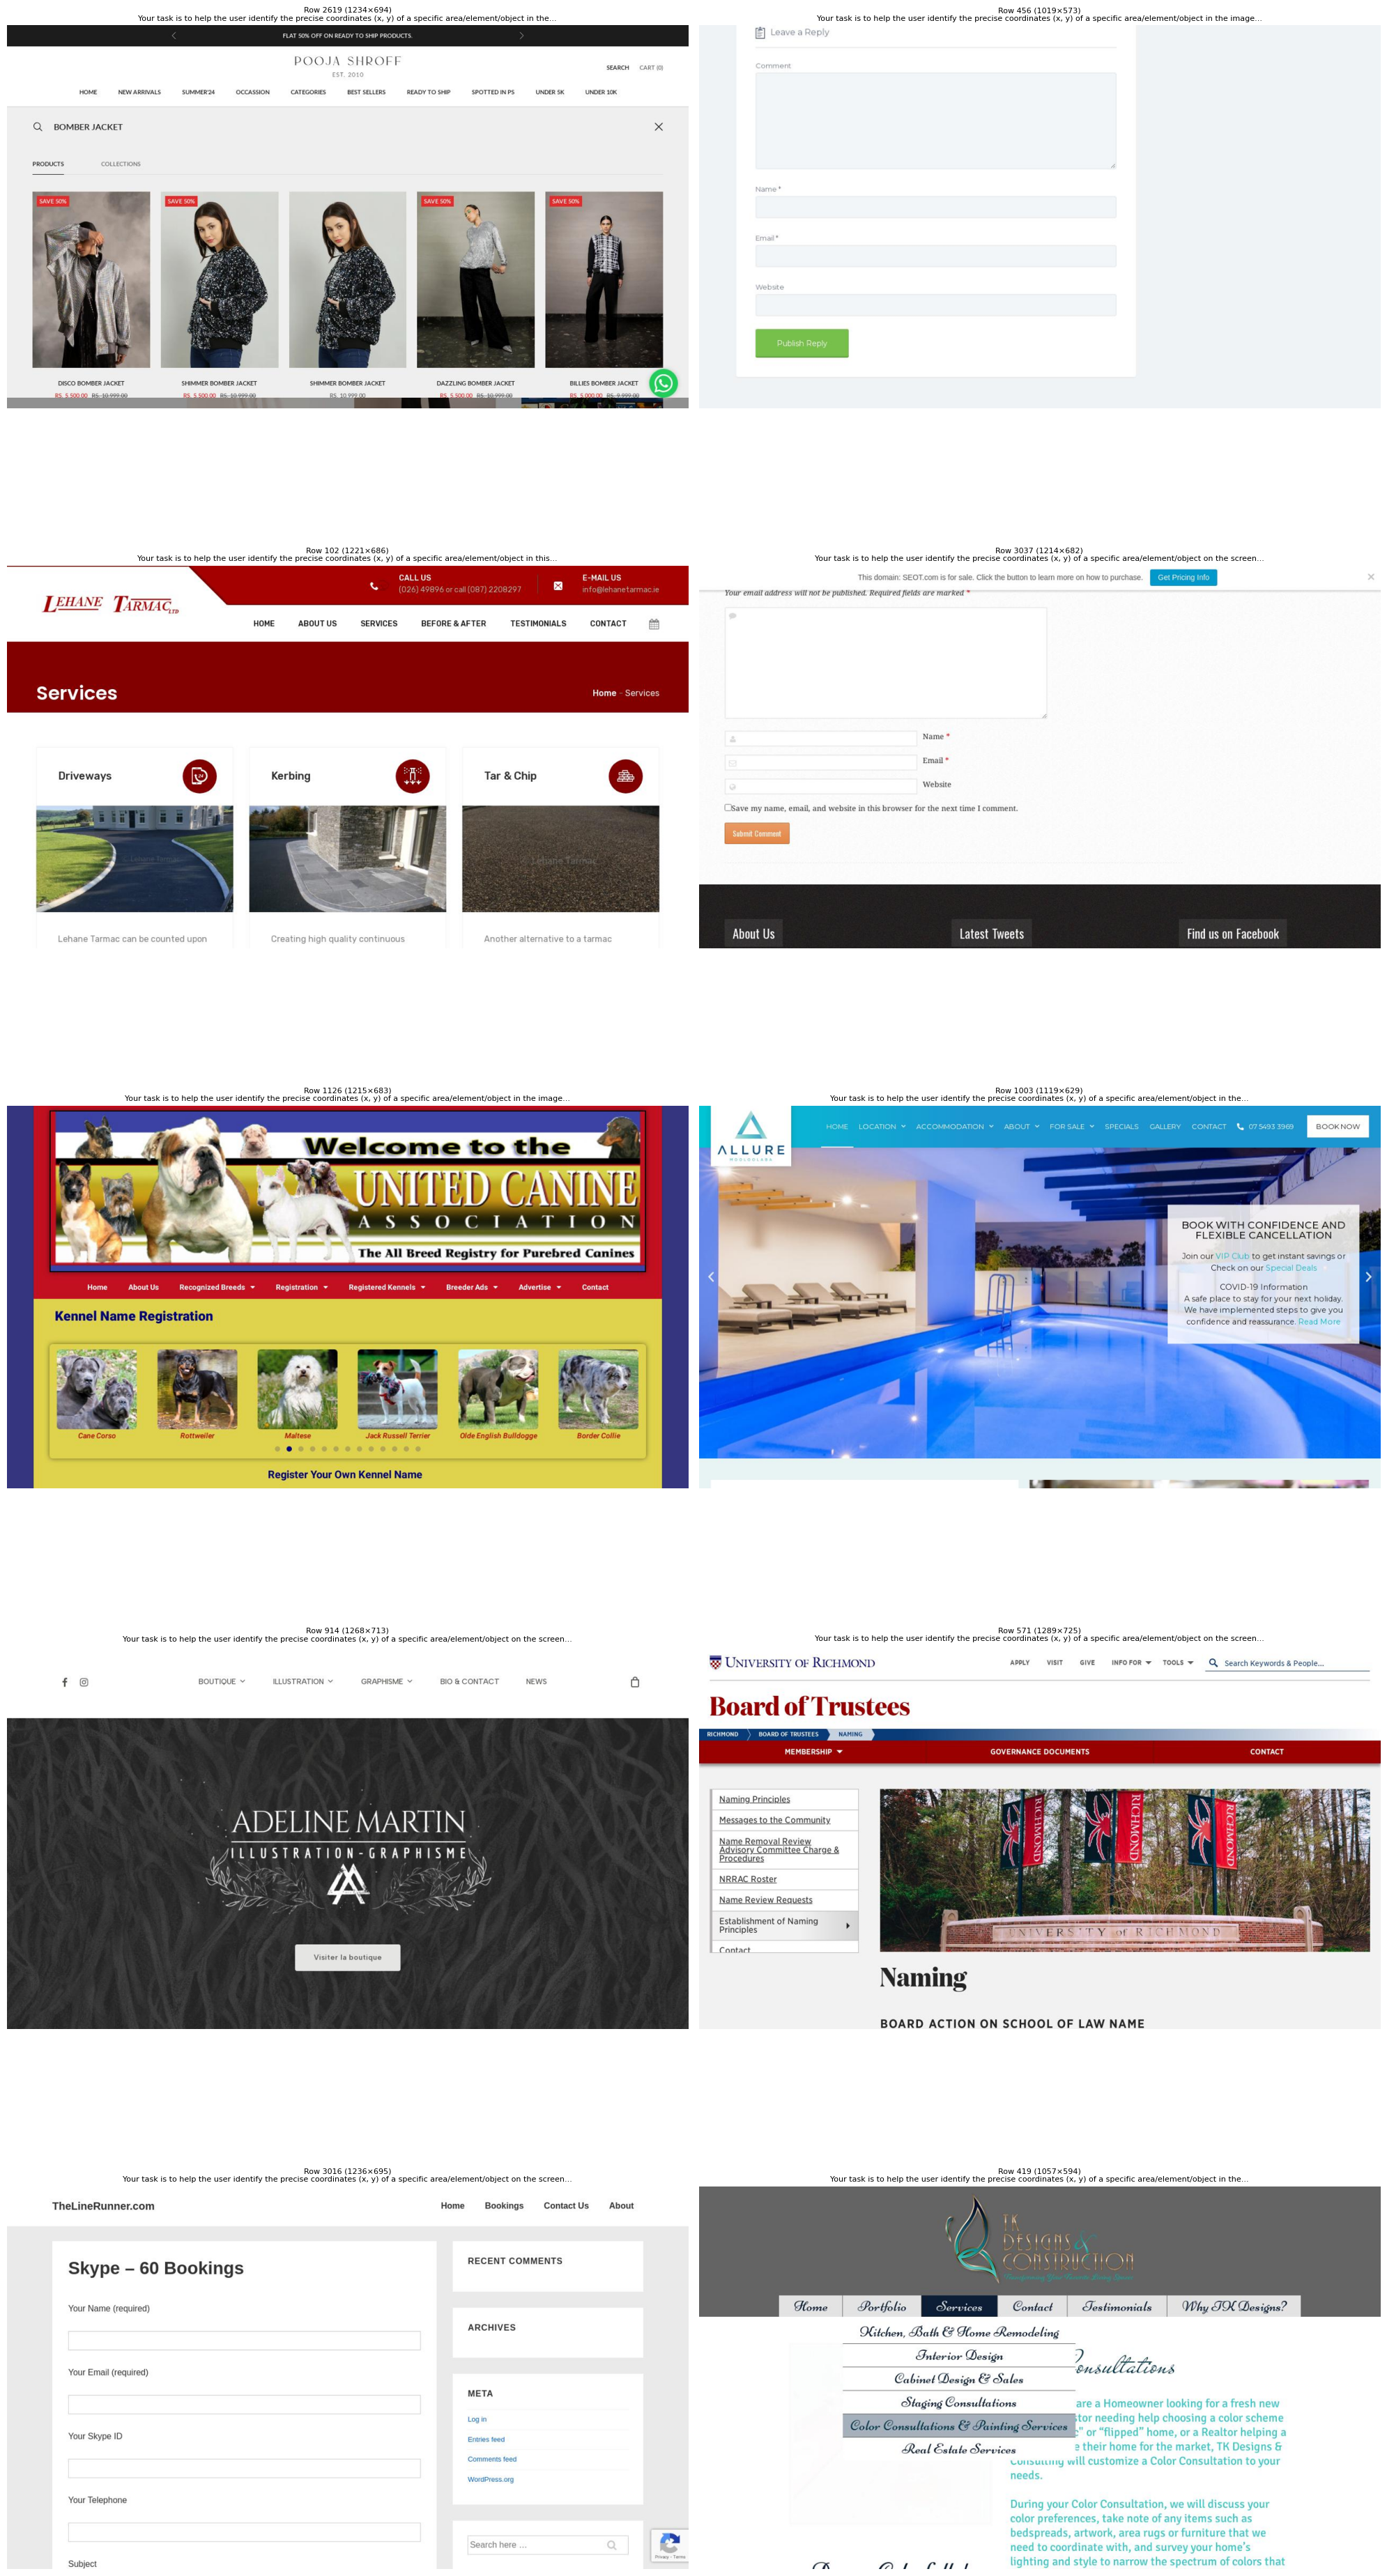

In [9]:
# DISPLAY 10 RANDOM IMAGES
# Each row's image column contains raw image bytes (PNG or JPEG). We decode them with PIL and display them in a grid with matplotlib. The first line of the human conversation turn is shown as the title so you can see what grounding task is being asked.

# Set a seed for reproducibility. Remove this line to get a different
# random selection each time you run the cell.
random.seed(42)

# Pick 10 random row indices from the dataset.
indices = random.sample(range(len(ds)), 10)

# Create a 5-row × 2-column grid of subplots.
fig, axes = plt.subplots(5, 2, figsize=(20, 40))
axes = axes.flatten()  # Flatten the 2D array of axes into a 1D list for easy iteration.

for ax, idx in zip(axes, indices):
    # Fetch the row from the dataset.
    row = ds[idx]

    # --- Decode the image ---
    # The "image" field can be:
    #   (a) raw bytes (if datasets didn't auto-decode) → open with PIL
    #   (b) a PIL Image (if datasets auto-decoded the Image feature)
    #   (c) a dict like {"bytes": ..., "path": ...} (some datasets versions)
    img = row["image"]
    if isinstance(img, bytes):
        # Case (a): raw bytes → wrap in BytesIO and open as a PIL Image.
        img = Image.open(io.BytesIO(img))
    elif isinstance(img, dict) and "bytes" in img:
        # Case (c): dict with a "bytes" key → extract and open.
        img = Image.open(io.BytesIO(img["bytes"]))
    # Case (b): already a PIL Image, no conversion needed.

    # --- Parse the conversation JSON ---
    # The "conversations" column is a JSON string containing a list of turns.
    # Each turn looks like: {"from": "human" or "gpt", "value": "..."}
    convos = json.loads(row["conversations"])

    # Extract the human turn's text for use as the plot title.
    human_msg = convos[0]["value"] if convos else ""

    # Remove the <image> placeholder tag that appears at the start of the prompt.
    human_msg = human_msg.replace("<image>", "").strip()

    # Truncate long prompts so they fit as a subplot title.
    title = textwrap.shorten(human_msg, width=120, placeholder="...")

    # Display the image in the subplot.
    ax.imshow(img)

    # Set the title showing the row index, image dimensions, and the prompt.
    ax.set_title(
        f"Row {idx} ({row['width']}×{row['height']})\n{title}",
        fontsize=8,
        wrap=True
    )

    # Hide the axis ticks and labels for a cleaner look.
    ax.axis("off")

# Adjust spacing between subplots so titles don't overlap.
plt.tight_layout()

# Render the figure.
plt.show()

In [ ]:
# INSPECT A SINGLE SAMPLE IN DETAIL
# Shows an example of a full conversation structure for a given row. The human turn describes a UI element to locate, and the GPT turn provides the (x, y) coordinates normalised to [0, 999].

# Pick one of the 10 random indices we already selected.
sample_idx = indices[0]

# Fetch the row.
sample = ds[sample_idx]

# Print the metadata.
print(f"Row index : {sample_idx}")
print(f"Image size: {sample['width']} × {sample['height']}")

# Parse and print each conversation turn.
print(f"\n--- Conversations ---")
convos = json.loads(sample["conversations"])
for turn in convos:
    # Uppercase the role for readability (HUMAN / GPT).
    role = turn["from"].upper()

    # Replace the <image> tag with a readable placeholder.
    text = turn["value"].replace("<image>", "[IMAGE]").strip()

    print(f"\n[{role}]\n{text}")

Row index : 41905
Image size: 1280 × 960

--- Conversations ---

[HUMAN]
[IMAGE]Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object in the image based on a description.

- Your response should aim to point to the center or a representative point within the described area/element/object as accurately as possible.
- If the description is unclear or ambiguous, infer the most relevant area or element based on its likely context or purpose.
- Your answer should be a single string (x, y) corresponding to the point of interest.

Description: My Shopping Cart

Answer:

[GPT]
(979, 23)

[HUMAN]
Description: My store:
COLUMBUS - WORTHINGTON, Display Store Information

Answer:

[GPT]
(84, 23)

[HUMAN]
Description: Fleet Feet home logo graphic link

Answer:

[GPT]
(125, 88)

[HUMAN]
Description: button for "GIFT CARDS", on the left side of the webpage

Answer:

[GPT]
(836, 23)

[HUMAN]
Description: link for "Gear"

Answer:

[GPT]
(573, 88)

[HUMA

## 2. EDA & Bias Audit

This section analyzes the UGround-V1-Data dataset for element type distribution, action verb bias, linguistic diversity, spatial bias, and resolution distribution.

### 2a. Streaming Sample (Full Dataset Stats)

We stream the full dataset to get unbiased statistics without downloading everything.

In [17]:
from datasets import load_dataset, get_dataset_config_names, get_dataset_split_names
import json

# ============================================================
# CONFIG — adjust sample size as needed
# ============================================================
SAMPLE_SIZE = 50_000       # number of records to analyze
DATASET_ID = "osunlp/UGround-V1-Data"
# ============================================================

# Step 1: Discover available configs and splits
print("Discovering dataset structure...")
try:
    configs = get_dataset_config_names(DATASET_ID)
    print(f"  Configs: {configs}")
except Exception as e:
    configs = ["default"]
    print(f"  Could not fetch configs ({e}), using 'default'")

config_name = configs[0]  # typically 'default'
try:
    splits = get_dataset_split_names(DATASET_ID, config_name)
    print(f"  Splits for '{config_name}': {splits}")
except Exception as e:
    splits = ["train"]
    print(f"  Could not fetch splits ({e}), using 'train'")

# Step 2: Pick which split to load
# Prefer 'web_hybrid' if it exists as a split, otherwise use 'train'
if "web_hybrid" in splits:
    SPLIT = "web_hybrid"
elif "train" in splits:
    SPLIT = "train"
else:
    SPLIT = splits[0]
print(f"\n→ Loading split '{SPLIT}' from config '{config_name}' in streaming mode...")

ds = load_dataset(DATASET_ID, config_name, streaming=True, split=SPLIT)

# Step 3: Collect sample (skip heavy image bytes)
records = []
for i, record in enumerate(ds):
    if i >= SAMPLE_SIZE:
        break
    try:
        convos = json.loads(record["conversations"]) if isinstance(record["conversations"], str) else record["conversations"]
    except (json.JSONDecodeError, TypeError):
        convos = []
    records.append({
        "width": record.get("width"),
        "height": record.get("height"),
        "conversations": convos,
    })
    if (i + 1) % 10000 == 0:
        print(f"  Loaded {i + 1:,} records...")

print(f"\nDone. Loaded {len(records):,} records from split '{SPLIT}'.")
print(f"Sample record columns: {list(record.keys()) if records else 'N/A'}")
print(f"\n💡 To analyze a different split, change SPLIT above to one of: {splits}")

Discovering dataset structure...
  Could not fetch configs (Dataset 'osunlp/UGround-V1-Data' is a gated dataset on the Hub. You must be authenticated to access it.), using 'default'
  Could not fetch splits (Dataset 'osunlp/UGround-V1-Data' is a gated dataset on the Hub. You must be authenticated to access it.), using 'train'

→ Loading split 'train' from config 'default' in streaming mode...


DatasetNotFoundError: Dataset 'osunlp/UGround-V1-Data' is a gated dataset on the Hub. You must be authenticated to access it.

In [ ]:
# Quick inspection — what does a conversation look like?
import pprint
for r in records[:3]:
    print(f"Resolution: {r['width']}x{r['height']}")
    pprint.pprint(r["conversations"])
    print("---")

Resolution: 1434x806
[{'from': 'human',
  'value': '<image>Your task is to help the user identify the precise '
           'coordinates (x, y) of a specific area/element/object on this '
           'screen based on a description.\n'
           '\n'
           '- Your response should aim to point to the center or a '
           'representative point within the described area/element/object as '
           'accurately as possible.\n'
           '- If the description is unclear or ambiguous, infer the most '
           'relevant area or element based on its likely context or purpose.\n'
           '- Your answer should be a single string (x, y) corresponding to '
           'the point of interest.\n'
           '\n'
           'Description: The navigation menu item labeled "PLUMBING" with a '
           'small downward-pointing arrow next to it, situated between the '
           '"ABOUT" and "HEATING & AIR CONDITIONING" menu items within the '
           'yellow navigation bar under the c

### 2b. Extract Referring Expressions & Coordinates

In [ ]:
import re

referring_expressions = []  # the human instructions
coordinates = []            # parsed (x, y) or (x1, y1, x2, y2) from assistant
resolutions = []            # (width, height)

for rec in records:
    resolutions.append((rec["width"], rec["height"]))
    convos = rec["conversations"]
    if not convos:
        continue

    for turn in convos:
        role = turn.get("from") or turn.get("role") or ""
        text = turn.get("value") or turn.get("content") or ""

        if role in ("human", "user"):
            # Strip system prompt boilerplate if present
            # The RE is usually after the task description
            referring_expressions.append(text)
        elif role in ("gpt", "assistant"):
            # Extract coordinates — format is typically (x, y) normalized to [0, 999]
            nums = re.findall(r'\d+', text)
            if len(nums) >= 2:
                coords = [int(n) for n in nums]
                coordinates.append(coords)

print(f"Extracted {len(referring_expressions):,} referring expressions")
print(f"Extracted {len(coordinates):,} coordinate sets")
print(f"Collected {len(resolutions):,} resolutions")
print(f"\nSample REs:")
for re_text in referring_expressions[:5]:
    print(f"  • {re_text[:120]}..." if len(re_text) > 120 else f"  • {re_text}")

Extracted 50,000 referring expressions
Extracted 50,000 coordinate sets
Collected 50,000 resolutions

Sample REs:
  • <image>Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object on this s...
  • <image>
Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object on this ...
  • <image>
Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object in the i...
  • <image>Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object on the sc...
  • <image>
Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object in the i...


### 2c. Element Type Distribution

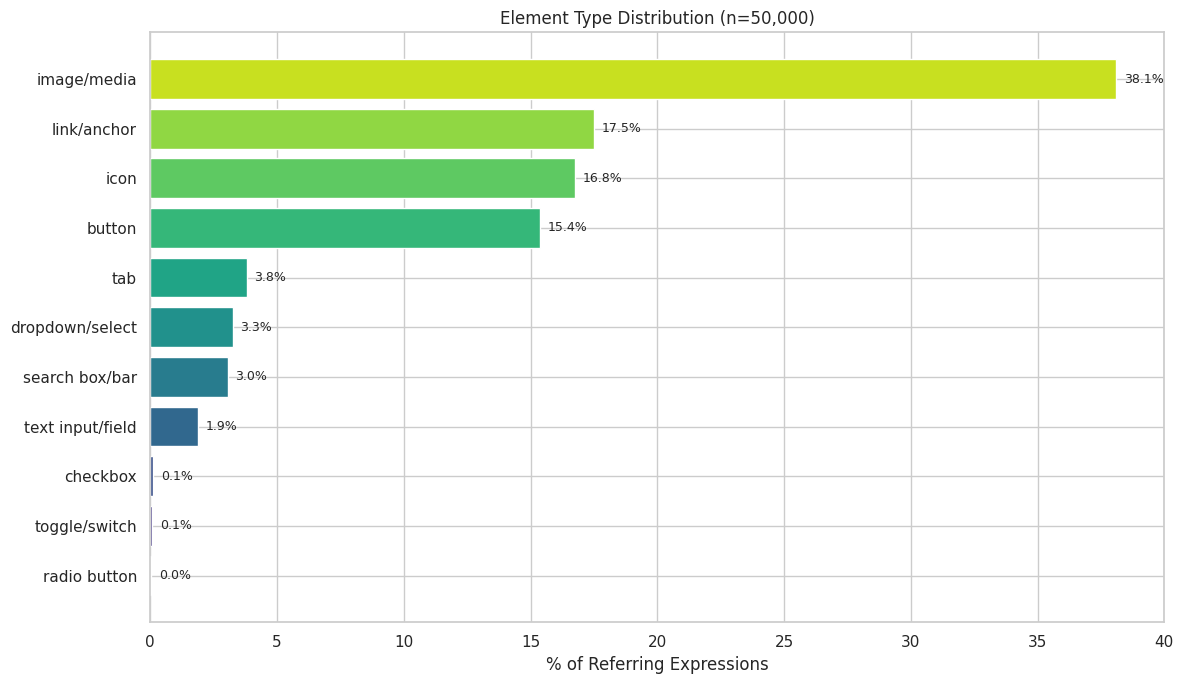


⚠️  Concentration check:
  image/media                38.1% ← POTENTIAL BIAS
  link/anchor                17.5%
  icon                       16.8%
  button                     15.4%
  tab                         3.8%
  dropdown/select             3.3%
  search box/bar              3.0%
  text input/field            1.9%
  checkbox                    0.1%
  toggle/switch               0.1%
  radio button                0.0%


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Element type keyword patterns (order matters — first match wins)
ELEMENT_PATTERNS = [
    ("search box/bar",    r"\b(search\s*(box|bar|field|input)|search icon)\b"),
    ("text input/field",  r"\b(text\s*(field|input|box|area)|input\s*(field|box)|textarea|form field|type\s*(in|into|here))\b"),
    ("button",            r"\b(button|btn|submit|click\s*(on|the)?\s*(button|btn))\b"),
    ("link/anchor",       r"\b(link|anchor|href|hyperlink|click\s*(on|the)?\s*link)\b"),
    ("dropdown/select",   r"\b(dropdown|select|combobox|drop-down|pulldown|menu\s*option)\b"),
    ("checkbox",          r"\b(checkbox|check\s*box|checkmark|tick\s*box)\b"),
    ("radio button",      r"\b(radio\s*(button|option)|radio)\b"),
    ("toggle/switch",     r"\b(toggle|switch|slider\s*switch)\b"),
    ("tab",               r"\b(tab|tab\s*bar|tab\s*menu)\b"),
    ("icon",              r"\b(icon|logo|favicon|symbol|glyph)\b"),
    ("image/media",       r"\b(image|photo|picture|thumbnail|video|media|img)\b"),
    ("navigation/menu",   r"\b(nav|navigation|menu|hamburger|sidebar|breadcrumb|toolbar)\b"),
    ("text/label",        r"\b(text|label|heading|title|paragraph|caption|header|footer)\b"),
    ("scroll",            r"\b(scroll|scrollbar|scroll\s*(up|down))\b"),
    ("modal/dialog",      r"\b(modal|dialog|popup|popover|overlay|tooltip)\b"),
    ("card/container",    r"\b(card|container|panel|section|div|block|widget|tile)\b"),
]

element_counts = Counter()
unclassified_samples = []

for re_text in referring_expressions:
    text_lower = re_text.lower()
    matched = False
    for label, pattern in ELEMENT_PATTERNS:
        if re.search(pattern, text_lower):
            element_counts[label] += 1
            matched = True
            break
    if not matched:
        element_counts["other/unclassified"] += 1
        if len(unclassified_samples) < 20:
            unclassified_samples.append(re_text[:150])

# Sort and plot
sorted_elements = element_counts.most_common()
labels, counts = zip(*sorted_elements)
total = sum(counts)
pcts = [c / total * 100 for c in counts]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(labels[::-1], pcts[::-1], color=sns.color_palette("viridis", len(labels)))
ax.set_xlabel("% of Referring Expressions")
ax.set_title(f"Element Type Distribution (n={total:,})")
for bar, pct in zip(bars, pcts[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n⚠️  Concentration check:")
for label, pct in zip(labels, pcts):
    flag = " ← POTENTIAL BIAS" if pct > 25 else ""
    print(f"  {label:25s} {pct:5.1f}%{flag}")

In [ ]:
# Inspect unclassified samples to see what we're missing
print("Sample unclassified REs (check if patterns need expanding):")
for s in unclassified_samples:
    print(f"  • {s}")

Sample unclassified REs (check if patterns need expanding):


### 2d. Action Verb Distribution

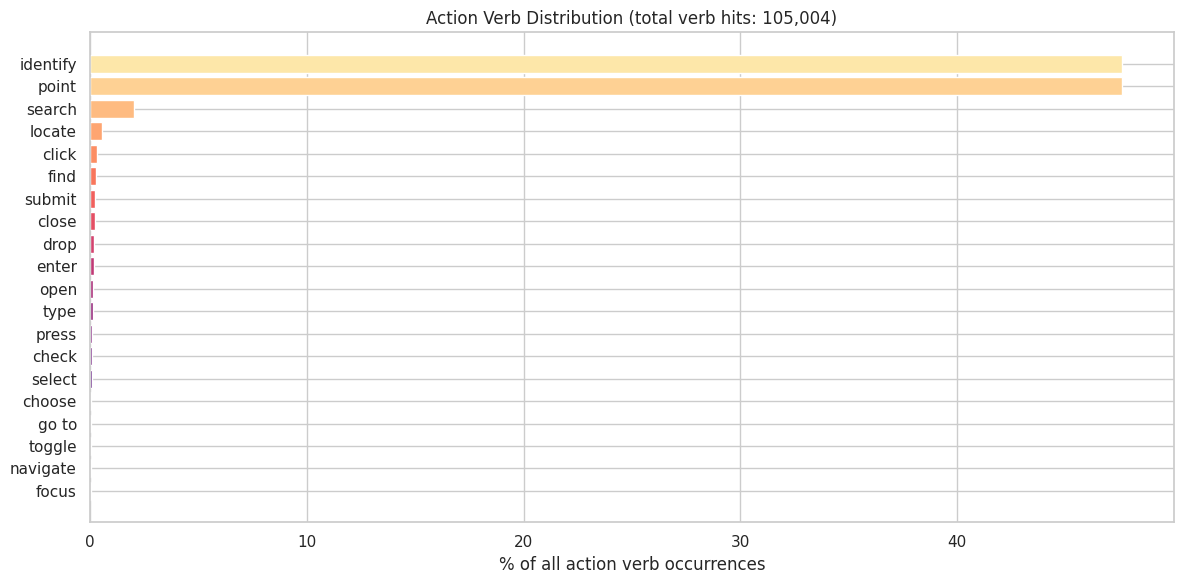


⚠️  Verb dominance check:
  'identify': 47.6% of all verb usage ← HEAVILY DOMINANT
  'point': 47.6% of all verb usage ← HEAVILY DOMINANT
  'search': 2.0% of all verb usage
  'locate': 0.5% of all verb usage
  'click': 0.3% of all verb usage


In [ ]:
ACTION_VERBS = [
    "click", "tap", "press", "select", "find", "locate", "identify",
    "point", "hover", "scroll", "type", "enter", "search", "open",
    "close", "expand", "collapse", "drag", "drop", "toggle",
    "check", "uncheck", "submit", "navigate", "go to", "switch",
    "choose", "pick", "highlight", "focus",
]

verb_counts = Counter()

for re_text in referring_expressions:
    text_lower = re_text.lower()
    for verb in ACTION_VERBS:
        if re.search(r'\b' + re.escape(verb) + r'\b', text_lower):
            verb_counts[verb] += 1

# Plot top verbs
top_verbs = verb_counts.most_common(20)
if top_verbs:
    v_labels, v_counts = zip(*top_verbs)
    v_total = sum(verb_counts.values())

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(v_labels[::-1], [c/v_total*100 for c in v_counts[::-1]],
            color=sns.color_palette("magma", len(v_labels)))
    ax.set_xlabel("% of all action verb occurrences")
    ax.set_title(f"Action Verb Distribution (total verb hits: {v_total:,})")
    plt.tight_layout()
    plt.show()

    # Dominance check
    print("\n⚠️  Verb dominance check:")
    for v, c in top_verbs[:5]:
        pct = c / v_total * 100
        flag = " ← HEAVILY DOMINANT" if pct > 30 else ""
        print(f"  '{v}': {pct:.1f}% of all verb usage{flag}")
else:
    print("No action verbs detected — REs may be noun-phrase only (e.g., 'the search box')")

### 2e. Linguistic Diversity

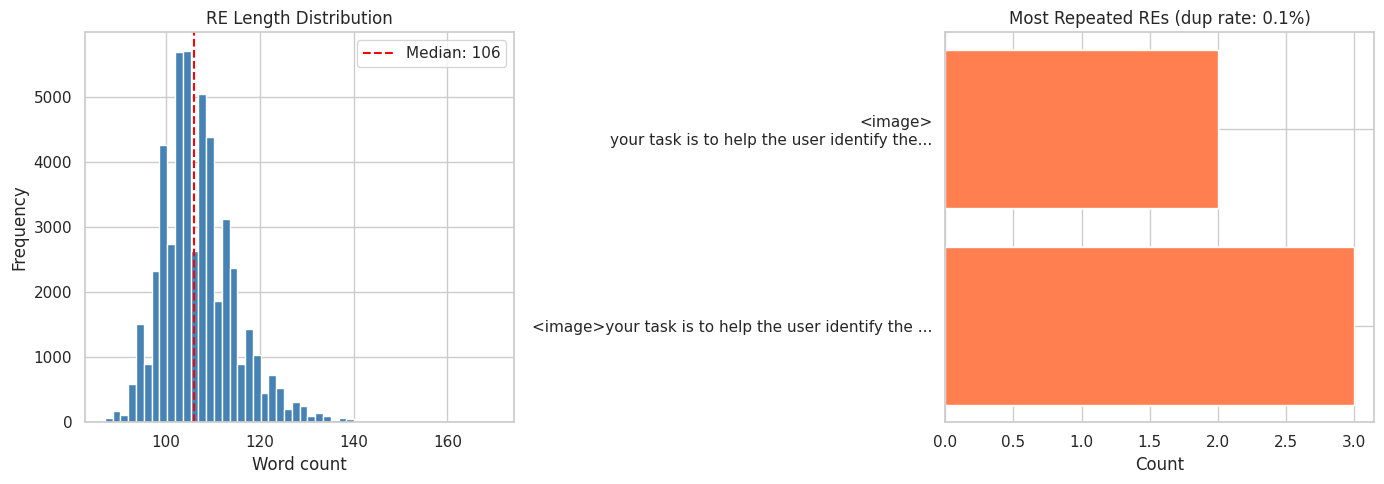


Total REs: 50,000
Unique REs: 49,951
Duplicate rate: 0.1%

⚠️  Duplication looks acceptable (0.1%)


In [ ]:
from collections import Counter
import math

# --- 5a. RE length distribution ---
re_lengths = [len(r.split()) for r in referring_expressions]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(re_lengths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("RE Length Distribution")
axes[0].axvline(np.median(re_lengths), color='red', linestyle='--', label=f'Median: {np.median(re_lengths):.0f}')
axes[0].legend()

# --- 5b. Exact duplicate rate ---
re_counter = Counter(r.lower().strip() for r in referring_expressions)
total_res = len(referring_expressions)
unique_res = len(re_counter)
dup_rate = (1 - unique_res / total_res) * 100

top_dupes = re_counter.most_common(15)
dupe_labels = [f"{t[:50]}..." if len(t) > 50 else t for t, _ in top_dupes]
dupe_counts = [c for _, c in top_dupes]

axes[1].barh(dupe_labels[::-1], dupe_counts[::-1], color="coral")
axes[1].set_xlabel("Count")
axes[1].set_title(f"Most Repeated REs (dup rate: {dup_rate:.1f}%)")

plt.tight_layout()
plt.show()

print(f"\nTotal REs: {total_res:,}")
print(f"Unique REs: {unique_res:,}")
print(f"Duplicate rate: {dup_rate:.1f}%")
print(f"\n⚠️  Duplication {'is a concern' if dup_rate > 20 else 'looks acceptable'} ({dup_rate:.1f}%)")

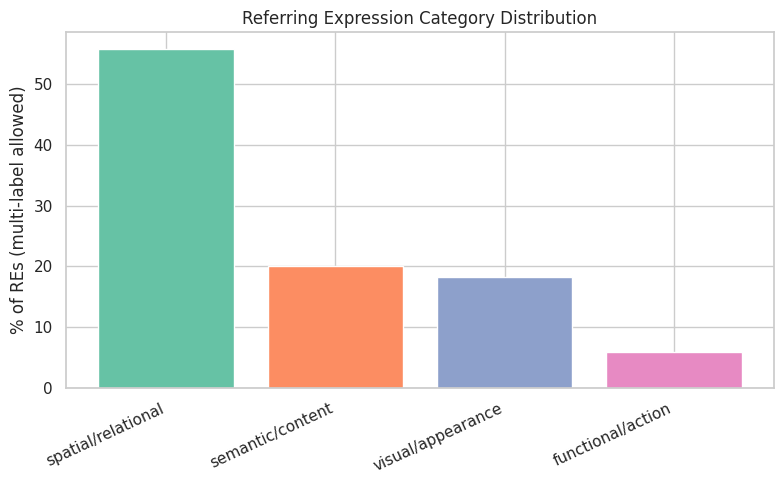


Multi-category REs: 30,500 (61.0%)
(Higher = more diverse/natural descriptions)


In [ ]:
# --- 5c. RE Category classification (visual / functional / semantic / spatial) ---

RE_CATEGORY_PATTERNS = {
    "visual/appearance": r"\b(color|colou?red|blue|red|green|white|black|gray|grey|yellow|orange|purple|pink|bold|italic|underline|large|small|big|round|square|bright|dark|transparent|outlined|filled|solid)\b",
    "spatial/relational": r"\b(above|below|left|right|next to|beside|under|over|top|bottom|between|near|corner|center|middle|adjacent|upper|lower|first|second|third|last)\b",
    "functional/action":  r"\b(click|tap|press|submit|login|sign.?in|sign.?up|search|download|upload|play|pause|delete|edit|save|send|buy|add to cart|checkout|subscribe|register|close|open|expand|collapse)\b",
    "semantic/content":   r"\b(says|reads|labeled|labelled|titled|named|shows|displays|contains|with text|that says|reading|written|caption|heading that)\b",
}

category_counts = Counter()
multi_category = 0

for re_text in referring_expressions:
    text_lower = re_text.lower()
    matches = []
    for cat, pattern in RE_CATEGORY_PATTERNS.items():
        if re.search(pattern, text_lower):
            matches.append(cat)
    if not matches:
        category_counts["uncategorized"] += 1
    else:
        for m in matches:
            category_counts[m] += 1
        if len(matches) > 1:
            multi_category += 1

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
cats = category_counts.most_common()
c_labels, c_counts = zip(*cats)
c_total = sum(c_counts)
ax.bar(c_labels, [c/c_total*100 for c in c_counts], color=sns.color_palette("Set2", len(c_labels)))
ax.set_ylabel("% of REs (multi-label allowed)")
ax.set_title("Referring Expression Category Distribution")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

print(f"\nMulti-category REs: {multi_category:,} ({multi_category/total_res*100:.1f}%)")
print("(Higher = more diverse/natural descriptions)")

### 2f. Spatial / Positional Bias

Coordinate points: 50,000


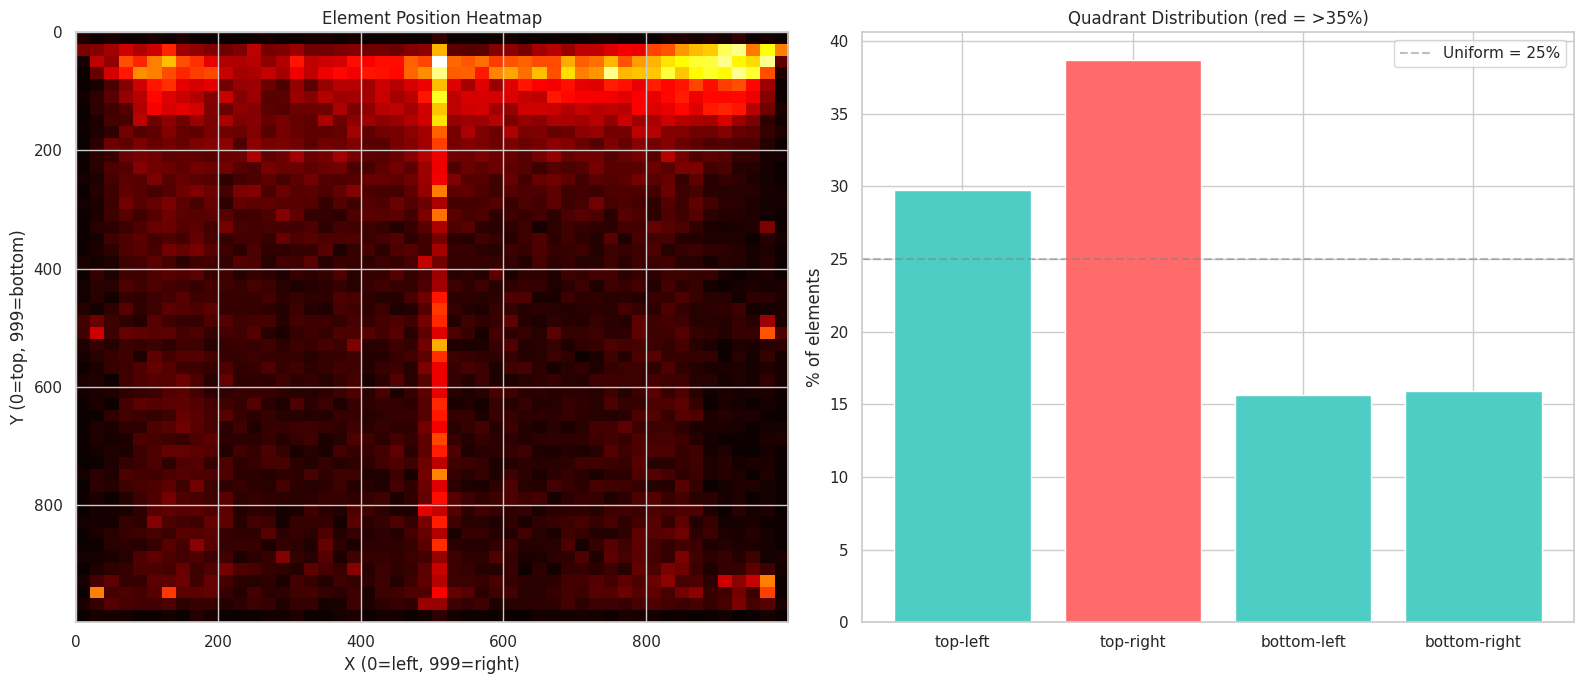


⚠️  Spatial balance check (uniform = 25% each):
  top-left         29.7%
  top-right        38.7% ← OVER-REPRESENTED
  bottom-left      15.7%
  bottom-right     15.9%


In [ ]:
# Extract (x, y) center points — take first two numbers as (x, y)
xs, ys = [], []
for coord in coordinates:
    if len(coord) == 2:
        xs.append(coord[0])
        ys.append(coord[1])
    elif len(coord) == 4:
        # Bounding box: use center point
        xs.append((coord[0] + coord[2]) / 2)
        ys.append((coord[1] + coord[3]) / 2)

print(f"Coordinate points: {len(xs):,}")

if xs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Heatmap
    heatmap, xedges, yedges = np.histogram2d(xs, ys, bins=50, range=[[0, 999], [0, 999]])
    axes[0].imshow(heatmap.T, origin='upper', extent=[0, 999, 999, 0],
                   cmap='hot', aspect='auto')
    axes[0].set_xlabel("X (0=left, 999=right)")
    axes[0].set_ylabel("Y (0=top, 999=bottom)")
    axes[0].set_title("Element Position Heatmap")

    # Quadrant analysis
    quadrants = Counter()
    for x, y in zip(xs, ys):
        h = "left" if x < 500 else "right"
        v = "top" if y < 500 else "bottom"
        quadrants[f"{v}-{h}"] += 1

    q_labels = ["top-left", "top-right", "bottom-left", "bottom-right"]
    q_vals = [quadrants.get(q, 0) / len(xs) * 100 for q in q_labels]
    colors = ["#ff6b6b" if v > 35 else "#4ecdc4" for v in q_vals]
    axes[1].bar(q_labels, q_vals, color=colors)
    axes[1].set_ylabel("% of elements")
    axes[1].set_title("Quadrant Distribution (red = >35%)")
    axes[1].axhline(25, color='gray', linestyle='--', alpha=0.5, label='Uniform = 25%')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\n⚠️  Spatial balance check (uniform = 25% each):")
    for q, v in zip(q_labels, q_vals):
        flag = " ← OVER-REPRESENTED" if v > 35 else (" ← UNDER-REPRESENTED" if v < 15 else "")
        print(f"  {q:15s} {v:5.1f}%{flag}")
else:
    print("No coordinates extracted — check parsing logic above.")

### 2g. Resolution & Aspect Ratio

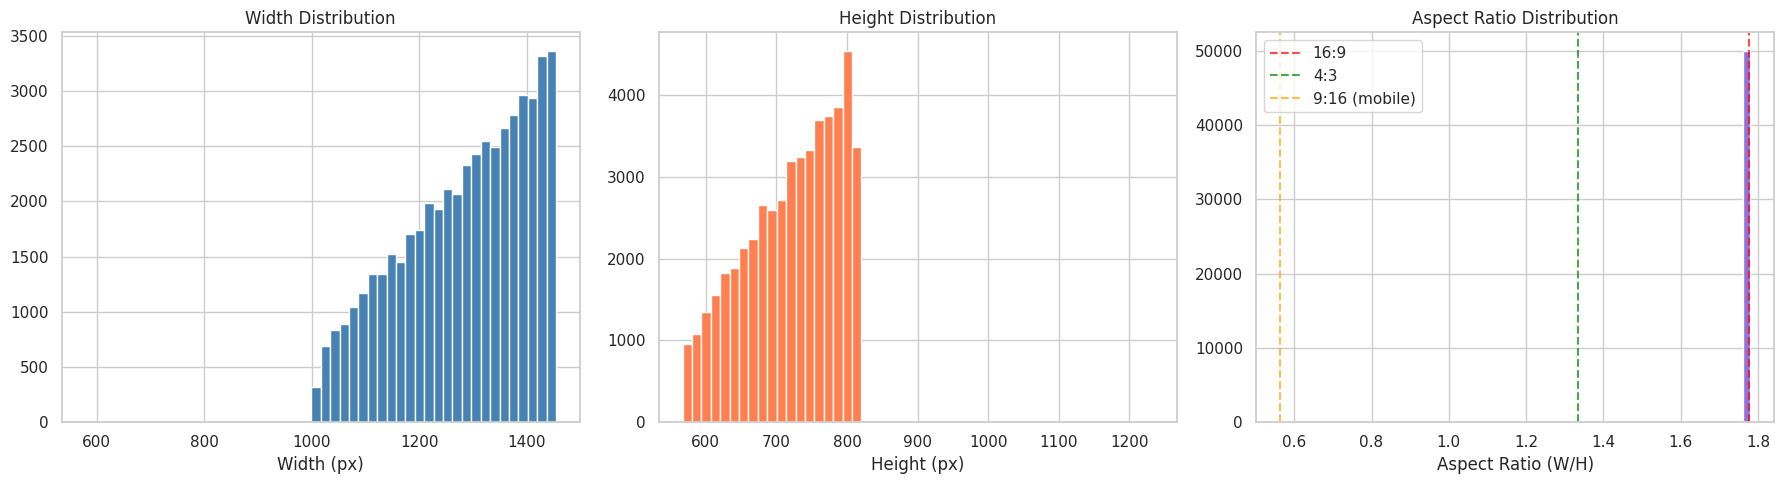


Top 10 resolutions:
  1454x817: 208 (0.4%)
  1449x815: 202 (0.4%)
  1442x811: 200 (0.4%)
  1439x809: 197 (0.4%)
  1413x794: 197 (0.4%)
  1446x813: 196 (0.4%)
  1397x785: 196 (0.4%)
  1437x808: 195 (0.4%)
  1440x810: 194 (0.4%)
  1428x803: 194 (0.4%)

Portrait (mobile-like, AR < 0.8): 1 (0.0%)
Landscape (desktop-like, AR >= 0.8): 49,999 (100.0%)


In [ ]:
widths = [r[0] for r in resolutions if r[0] and r[1]]
heights = [r[1] for r in resolutions if r[0] and r[1]]
aspects = [w/h for w, h in zip(widths, heights) if h > 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Width (px)")
axes[0].set_title("Width Distribution")

axes[1].hist(heights, bins=50, color="coral", edgecolor="white")
axes[1].set_xlabel("Height (px)")
axes[1].set_title("Height Distribution")

axes[2].hist(aspects, bins=50, color="mediumpurple", edgecolor="white")
axes[2].set_xlabel("Aspect Ratio (W/H)")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].axvline(16/9, color='red', linestyle='--', alpha=0.7, label='16:9')
axes[2].axvline(4/3, color='green', linestyle='--', alpha=0.7, label='4:3')
axes[2].axvline(9/16, color='orange', linestyle='--', alpha=0.7, label='9:16 (mobile)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Resolution clustering
res_counter = Counter(resolutions)
print("\nTop 10 resolutions:")
for (w, h), count in res_counter.most_common(10):
    pct = count / len(resolutions) * 100
    print(f"  {w}x{h}: {count:,} ({pct:.1f}%)")

# Mobile vs desktop heuristic
portrait = sum(1 for a in aspects if a < 0.8)  # portrait / mobile-ish
landscape = sum(1 for a in aspects if a >= 0.8)
print(f"\nPortrait (mobile-like, AR < 0.8): {portrait:,} ({portrait/len(aspects)*100:.1f}%)")
print(f"Landscape (desktop-like, AR >= 0.8): {landscape:,} ({landscape/len(aspects)*100:.1f}%)")

### 2h. N-gram Analysis (Template Detection)

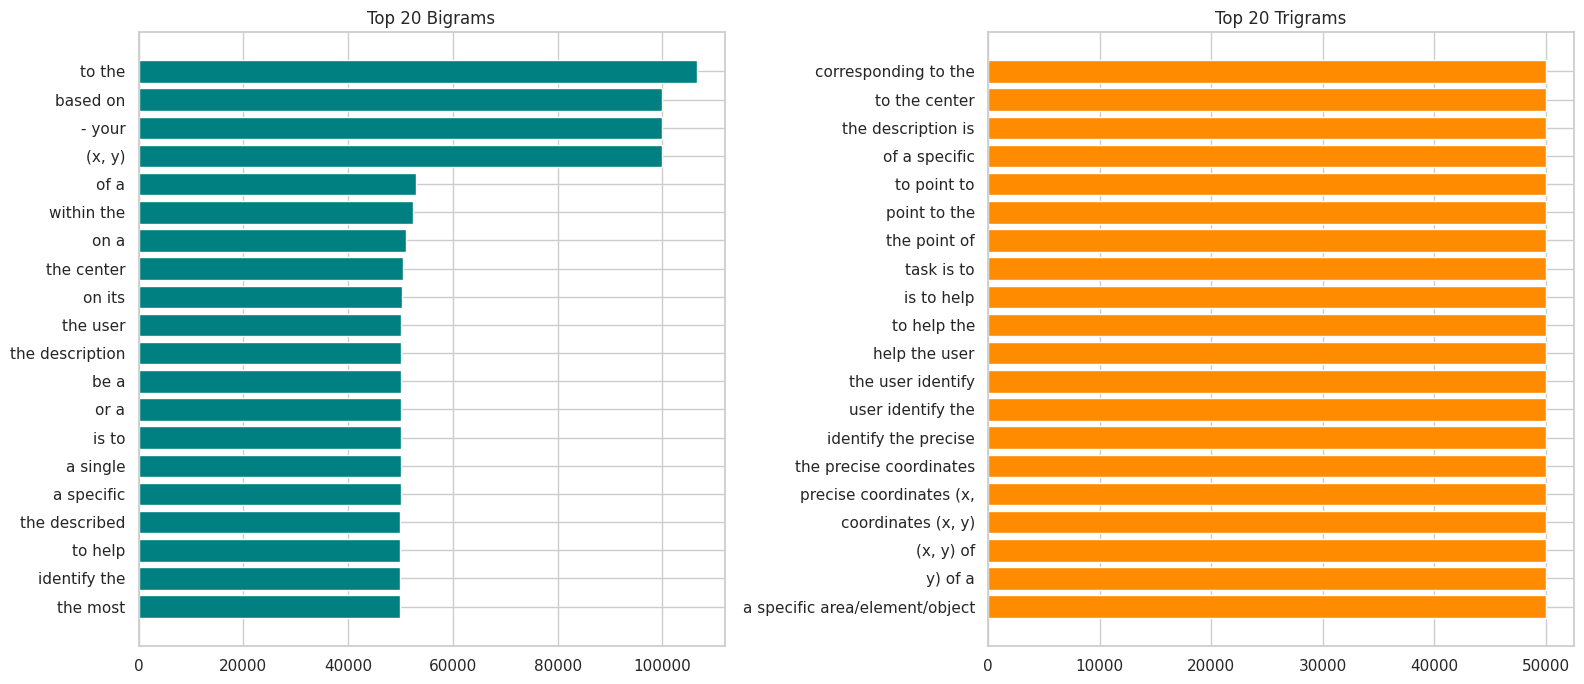


Most common trigram: 'corresponding to the' appears in 100.0% of REs
⚠️  High trigram concentration suggests templated generation


In [ ]:
from collections import Counter

def get_ngrams(text, n):
    words = text.lower().split()
    return [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]

bigrams = Counter()
trigrams = Counter()

for re_text in referring_expressions:
    for bg in get_ngrams(re_text, 2):
        bigrams[bg] += 1
    for tg in get_ngrams(re_text, 3):
        trigrams[tg] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_bg = bigrams.most_common(20)
if top_bg:
    bg_labels, bg_counts = zip(*top_bg)
    axes[0].barh(bg_labels[::-1], bg_counts[::-1], color="teal")
    axes[0].set_title("Top 20 Bigrams")

top_tg = trigrams.most_common(20)
if top_tg:
    tg_labels, tg_counts = zip(*top_tg)
    axes[1].barh(tg_labels[::-1], tg_counts[::-1], color="darkorange")
    axes[1].set_title("Top 20 Trigrams")

plt.tight_layout()
plt.show()

# Template detection: if top trigram covers >5% of data, it's likely templated
if top_tg:
    top_tg_pct = top_tg[0][1] / total_res * 100
    print(f"\nMost common trigram: '{top_tg[0][0]}' appears in {top_tg_pct:.1f}% of REs")
    if top_tg_pct > 5:
        print("⚠️  High trigram concentration suggests templated generation")
    else:
        print("✓  Trigram distribution looks reasonably diverse")

### 2i. Summary Report

In [ ]:
print("=" * 60)
print("  UGROUND-V1-DATA BIAS AUDIT SUMMARY")
print(f"  Split: {SPLIT} | Sample: {len(records):,} records")
print("=" * 60)

findings = []

# Element type concentration
if sorted_elements:
    top_element_pct = sorted_elements[0][1] / total * 100
    if top_element_pct > 25:
        findings.append(f"🔴 Element type '{sorted_elements[0][0]}' dominates at {top_element_pct:.1f}%")
    else:
        findings.append(f"🟢 No single element type exceeds 25% (top: {sorted_elements[0][0]} at {top_element_pct:.1f}%)")

# RE duplication
if dup_rate > 20:
    findings.append(f"🔴 High RE duplication rate: {dup_rate:.1f}%")
elif dup_rate > 10:
    findings.append(f"🟡 Moderate RE duplication rate: {dup_rate:.1f}%")
else:
    findings.append(f"🟢 Low RE duplication rate: {dup_rate:.1f}%")

# Spatial bias
if xs:
    max_quadrant_pct = max(q_vals)
    if max_quadrant_pct > 35:
        findings.append(f"🔴 Spatial bias detected: one quadrant has {max_quadrant_pct:.1f}% of elements")
    else:
        findings.append(f"🟢 Spatial distribution is reasonably balanced (max quadrant: {max_quadrant_pct:.1f}%)")

# Verb dominance
if top_verbs:
    top_verb_pct = top_verbs[0][1] / v_total * 100
    if top_verb_pct > 30:
        findings.append(f"🔴 Action verb '{top_verbs[0][0]}' dominates at {top_verb_pct:.1f}%")
    else:
        findings.append(f"🟢 Action verb distribution is balanced (top: '{top_verbs[0][0]}' at {top_verb_pct:.1f}%)")

# Resolution diversity
if resolutions:
    top_res_pct = res_counter.most_common(1)[0][1] / len(resolutions) * 100
    if top_res_pct > 50:
        findings.append(f"🔴 Resolution heavily concentrated: top resolution = {top_res_pct:.1f}%")
    else:
        findings.append(f"🟢 Resolution diversity is reasonable (top resolution = {top_res_pct:.1f}%)")

# Platform skew (known from paper)
findings.append("🟡 Known: ~95% web-sourced data — mobile/desktop coverage is limited")

print()
for f in findings:
    print(f"  {f}")
print()
print("=" * 60)
print("  Next steps:")
print("  • Increase SAMPLE_SIZE for higher confidence")
print("  • Run on 'web_direct' subset and compare")
print("  • Sample & visually inspect screenshots for domain diversity")
print("  • Cross-check against your downstream task's element needs")
print("=" * 60)

  UGROUND-V1-DATA BIAS AUDIT SUMMARY
  Split: train | Sample: 50,000 records

  🔴 Element type 'image/media' dominates at 38.1%
  🟢 Low RE duplication rate: 0.1%
  🔴 Spatial bias detected: one quadrant has 38.7% of elements
  🔴 Action verb 'identify' dominates at 47.6%
  🟢 Resolution diversity is reasonable (top resolution = 0.4%)
  🟡 Known: ~95% web-sourced data — mobile/desktop coverage is limited

  Next steps:
  • Increase SAMPLE_SIZE for higher confidence
  • Run on 'web_direct' subset and compare
  • Sample & visually inspect screenshots for domain diversity
  • Cross-check against your downstream task's element needs


## 3. Data Quality Analysis

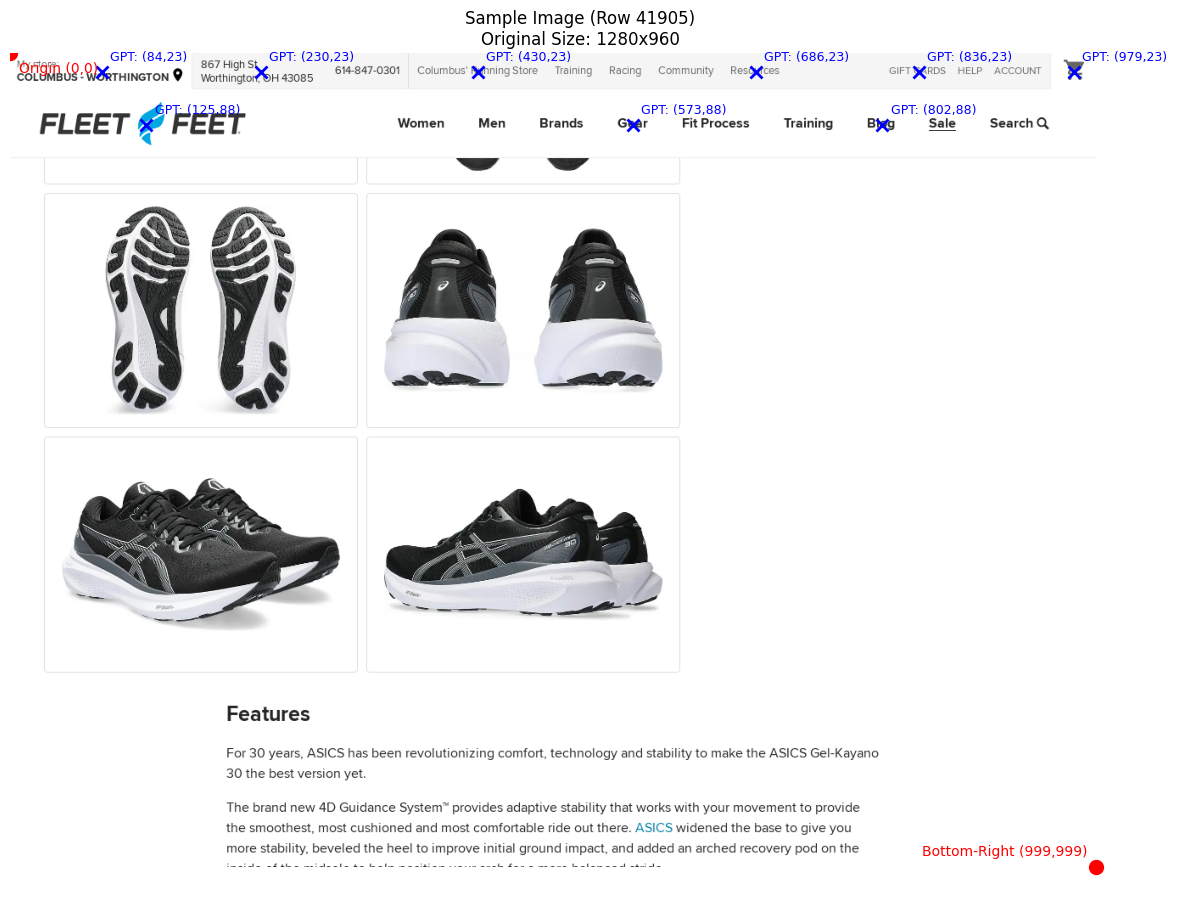

Image dimensions: Width=1280 pixels, Height=960 pixels

--- Conversations for Row 41905 ---
{ role: human, value: 'Your task is to help the user identify the precise coordinates (x, y) of a specific...' }
{ role: gpt, value: '(979, 23)' }
{ role: human, value: 'Description: My store: COLUMBUS - WORTHINGTON, Display Store Information Answer:' }
{ role: gpt, value: '(84, 23)' }
{ role: human, value: 'Description: Fleet Feet home logo graphic link Answer:' }
{ role: gpt, value: '(125, 88)' }
{ role: human, value: 'Description: button for "GIFT CARDS", on the left side of the webpage Answer:' }
{ role: gpt, value: '(836, 23)' }
{ role: human, value: 'Description: link for "Gear" Answer:' }
{ role: gpt, value: '(573, 88)' }
{ role: human, value: 'Description: Columbus' Running Store link, to the bottom left of "Men" Answer:' }
{ role: gpt, value: '(430, 23)' }
{ role: human, value: 'Description: Blog Answer:' }
{ role: gpt, value: '(802, 88)' }
{ role: human, value: 'Description: button lab

In [ ]:
import matplotlib.pyplot as plt
import io
from PIL import Image
import json
import textwrap

# Define the coordinate range for visualization
MIN_COORD = 0
MAX_COORD = 999

# We'll use the same sample_idx as before for consistency
# Ensure 'ds' and 'indices' are available from previous runs
if 'ds' not in locals() or 'indices' not in locals():
    print("Please run previous cells to load the dataset and select indices.")
    # Fallback if ds or indices are not defined for some reason
    # For this demonstration, we'll assume they are present. If not, this might error.
    if 'ds' not in locals():
        # This part would typically load ds if it wasn't already
        # For this example, we assume ds is loaded.
        pass
    if 'indices' not in locals():
        import random
        random.seed(42)
        indices = random.sample(range(len(ds)), 10)

sample_idx = indices[0] # Using the first selected random sample (e.g., 41905)
sample = ds[sample_idx]

# --- Display the image ---
# Decode the image
img = sample["image"]
if isinstance(img, bytes):
    img = Image.open(io.BytesIO(img))
elif isinstance(img, dict) and "bytes" in img:
    img = Image.open(io.BytesIO(img["bytes"]))

original_width = sample["width"]
original_height = sample["height"]

plt.figure(figsize=(12, 10))
plt.imshow(img)

# --- Visualize the (0,0) and (999,999) corners of the normalized grid ---
# Convert normalized corners to original pixel coordinates
pixel_0_0_x = int(round(MIN_COORD / MAX_COORD * original_width))
pixel_0_0_y = int(round(MIN_COORD / MAX_COORD * original_height))
pixel_999_999_x = int(round(MAX_COORD / MAX_COORD * original_width))
pixel_999_999_y = int(round(MAX_COORD / MAX_COORD * original_height))

# Plot the (0,0) origin
plt.plot(pixel_0_0_x, pixel_0_0_y, 'ro', markersize=10, label='(0,0) Origin (Normalized)')
plt.text(pixel_0_0_x + 10, pixel_0_0_y + 10, f'Origin (0,0)', color='red', fontsize=10, ha='left', va='top')

# Plot the (999,999) bottom-right corner
plt.plot(pixel_999_999_x, pixel_999_999_y, 'ro', markersize=10, label='(999,999) Bottom-Right (Normalized)')
plt.text(pixel_999_999_x - 10, pixel_999_999_y - 10, f'Bottom-Right (999,999)', color='red', fontsize=10, ha='right', va='bottom')


# --- Display dimensions and plot GPT conversation points ---
convos = json.loads(sample["conversations"])

# Collect GPT points for plotting
gpt_points = []
for turn_idx, turn in enumerate(convos):
    if turn["from"] == "gpt":
        value = turn["value"]
        match = re.fullmatch(r"\(([-]?\d+),\s*([-]?\d+)\)", value)
        if match:
            try:
                normalized_x = int(match.group(1))
                normalized_y = int(match.group(2))

                # Convert normalized coordinates to original pixel coordinates
                pixel_x = int(round(normalized_x / MAX_COORD * original_width))
                pixel_y = int(round(normalized_y / MAX_COORD * original_height))

                gpt_points.append(((pixel_x, pixel_y), (normalized_x, normalized_y)))
            except ValueError:
                pass # Skip if coordinates are not valid numbers

# Plot GPT points
for (px, py), (nx, ny) in gpt_points:
    plt.plot(px, py, 'bx', markersize=8, markeredgewidth=2) # Blue 'x' for GPT points
    plt.text(px + 10, py - 10, f'GPT: ({nx},{ny})', color='blue', fontsize=9, ha='left', va='bottom')


plt.title(f"Sample Image (Row {sample_idx})\nOriginal Size: {original_width}x{original_height}")
plt.axis("off")
plt.tight_layout()
plt.show()

# --- Display dimensions ---
print(f"Image dimensions: Width={original_width} pixels, Height={original_height} pixels")

# --- Display conversations in requested format ---
print(f"\n--- Conversations for Row {sample_idx} ---")
for turn in convos:
    role = turn["from"]
    # Clean the value, remove <image> and strip whitespace
    value = turn["value"].replace("<image>", "").strip()
    # For displaying, ensure multi-line values are presented on one line for brevity or wrapped
    display_value = textwrap.shorten(value.replace('\n', ' '), width=100, placeholder='...')
    print(f"{{ role: {role}, value: '{display_value}' }}")


Collected dimensions for 10000/43392 rows...
Collected dimensions for 20000/43392 rows...
Collected dimensions for 30000/43392 rows...
Collected dimensions for 40000/43392 rows...
Image dimension collection complete.

Maximum image width observed: 1455 pixels
Maximum image height observed: 1680 pixels


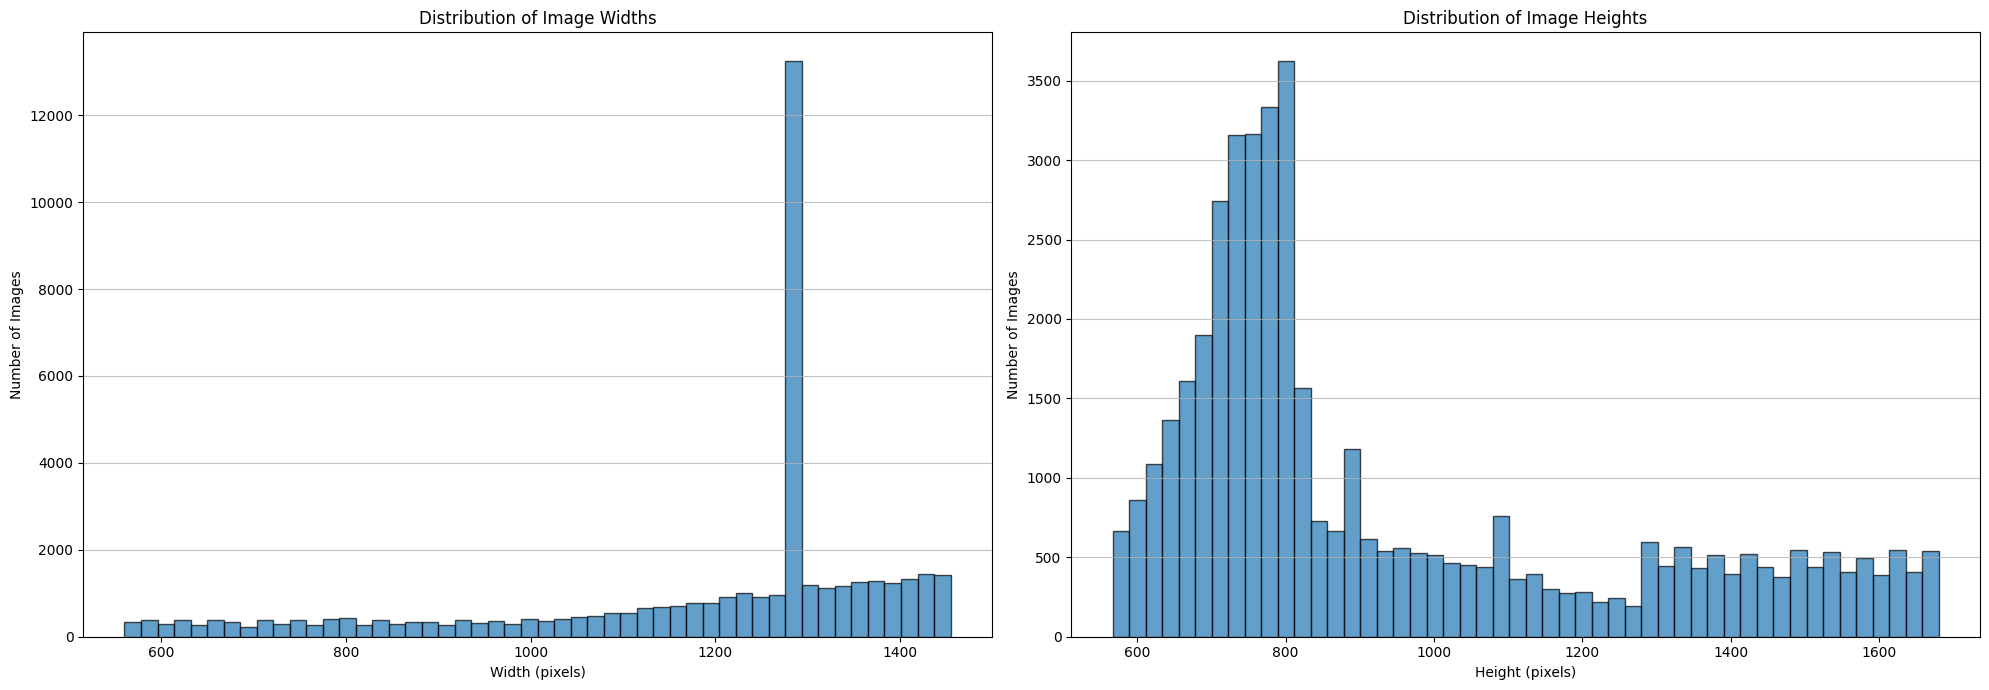

In [ ]:
image_widths = []
image_heights = []

print("Collecting image dimensions...")

for i, row in enumerate(ds):
    image_widths.append(row["width"])
    image_heights.append(row["height"])
    if (i + 1) % 10000 == 0:
        print(f"Collected dimensions for {i + 1}/{len(ds)} rows...")

print("Image dimension collection complete.")

max_width = max(image_widths)
max_height = max(image_heights)

print(f"\nMaximum image width observed: {max_width} pixels")
print(f"Maximum image height observed: {max_height} pixels")

# Create histograms
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Histogram for Widths
n_width, bins_width, patches_width = axes[0].hist(image_widths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Image Widths')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Number of Images')
axes[0].grid(axis='y', alpha=0.75)
# Add labels on top of bars for widths
for i in range(len(patches_width)):
    if n_width[i] > 0: # Only label bars that have a count
        axes[0].text(patches_width[i].get_x() + patches_width[i].get_width() / 2,
                     patches_width[i].get_height(),
                     f'{int(n_width[i])}', ha='center', va='bottom', fontsize=7)

# Histogram for Heights
n_height, bins_height, patches_height = axes[1].hist(image_heights, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Image Heights')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Number of Images')
axes[1].grid(axis='y', alpha=0.75)
# Add labels on top of bars for heights
for i in range(len(patches_height)):
    if n_height[i] > 0: # Only label bars that have a count
        axes[1].text(patches_height[i].get_x() + patches_height[i].get_width() / 2,
                     patches_height[i].get_height(),
                     f'{int(n_height[i])}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
import collections

resolution_pairs = []
for row in ds:
    resolution_pairs.append((row["width"], row["height"]))

resolution_counts = collections.Counter(resolution_pairs)

print("Top 10 most common resolution pairs:")
for pair, count in resolution_counts.most_common(10):
    print(f"  {pair[0]}x{pair[1]}: {count} occurrences")

print(f"\nTotal unique resolution pairs: {len(resolution_counts)}")


Top 10 most common resolution pairs:
  1280x720: 787 occurrences
  1280x740: 716 occurrences
  1280x780: 713 occurrences
  1280x760: 710 occurrences
  1280x800: 683 occurrences
  1280x820: 646 occurrences
  1280x840: 625 occurrences
  1280x860: 581 occurrences
  1280x880: 557 occurrences
  1280x920: 534 occurrences

Total unique resolution pairs: 6982


Calculating conversation lengths...
Processed 10000/43392 rows...
Processed 20000/43392 rows...
Processed 30000/43392 rows...
Processed 40000/43392 rows...
Conversation length calculation complete.


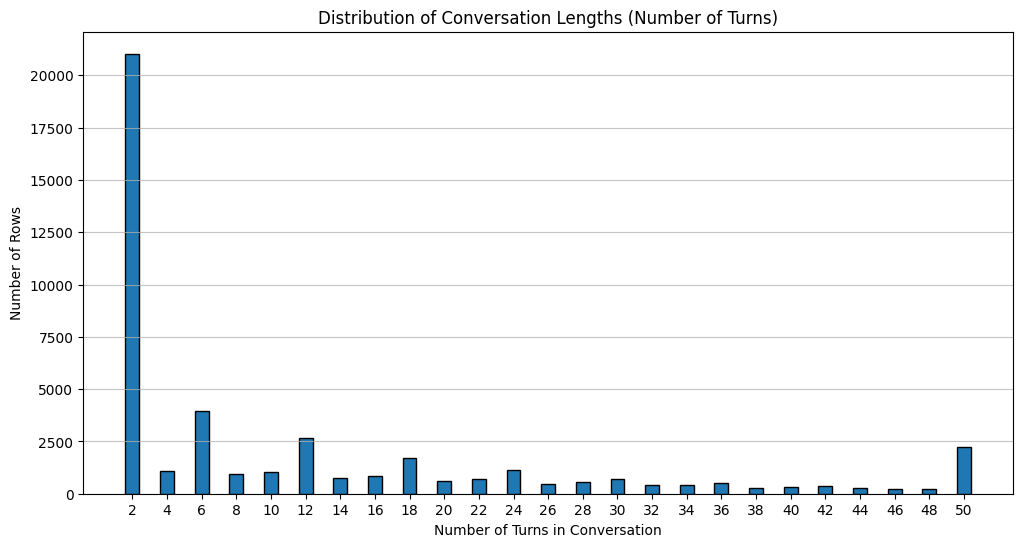

In [ ]:
import collections
import matplotlib.pyplot as plt

conversation_lengths = []

print("Calculating conversation lengths...")

for i, row in enumerate(ds):
    try:
        convos = json.loads(row["conversations"])
        conversation_lengths.append(len(convos))
    except json.JSONDecodeError:
        # Handle rows where JSON might be malformed (though our earlier check found none)
        print(f"Warning: Could not parse conversations for row {i}")
        conversation_lengths.append(0) # Assign 0 or -1 for unparseable entries
    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1}/{len(ds)} rows...")

print("Conversation length calculation complete.")

# Using collections.Counter and plt.bar for clearer discrete counts
length_counts = collections.Counter(conversation_lengths)
sorted_lengths = sorted(length_counts.keys())
counts = [length_counts[length] for length in sorted_lengths]

plt.figure(figsize=(12, 6))
plt.bar(sorted_lengths, counts, edgecolor='black', align='center', width=0.8) # Use bar plot
plt.title('Distribution of Conversation Lengths (Number of Turns)')
plt.xlabel('Number of Turns in Conversation')
plt.ylabel('Number of Rows')
plt.xticks(sorted_lengths) # Set ticks directly at the center of each bar for each length
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import json
import re

# List to store information about non-conforming GPT responses
non_coordinate_gpt_responses = []

# Define the expected coordinate range
MIN_COORD = 0
MAX_COORD = 999

print("Starting analysis for non-conforming GPT coordinate responses...")

for i, row in enumerate(ds):
    try:
        convos = json.loads(row["conversations"])
        for turn_idx, turn in enumerate(convos):
            if turn.get("from") == "gpt":
                value = turn.get("value", "").strip()

                # Updated regex to allow for optional negative signs before digits
                match = re.fullmatch(r"\(([-]?\d+),\s*([-]?\d+)\)", value)

                if match:
                    try:
                        x = int(match.group(1))
                        y = int(match.group(2))
                        # Explicitly check if coordinates are within the expected range
                        if not (MIN_COORD <= x <= MAX_COORD and MIN_COORD <= y <= MAX_COORD):
                            non_coordinate_gpt_responses.append(
                                (i, turn_idx, value, f"Coordinates out of bounds: ({x},{y})")
                            )
                    except ValueError:
                        # This catch-all is less likely now with the updated regex, but good practice
                        non_coordinate_gpt_responses.append(
                            (i, turn_idx, value, "Non-numeric coordinate values despite regex match")
                        )
                else:
                    # This GPT response does not fit the (x, y) format at all
                    non_coordinate_gpt_responses.append(
                        (i, turn_idx, value, "Does not match (x, y) coordinate format")
                    )

    except json.JSONDecodeError:
        non_coordinate_gpt_responses.append((i, -1, "N/A", "JSON parsing error in conversations"))

    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1}/{len(ds)} rows...")

print("\n--- Non-conforming GPT Coordinate Responses Analysis Results ---")
print(f"Total rows processed: {len(ds)}")

if non_coordinate_gpt_responses:
    print(f"Found {len(non_coordinate_gpt_responses)} issues where GPT responses were not valid (x, y) coordinates within [0, 999].")
    print("Examples (row_idx, turn_idx, actual_value, issue):")
    for issue in non_coordinate_gpt_responses[:10]: # Display up to 10 examples
        print(f"  Row {issue[0]}, Turn {issue[1]}: '{issue[2]}' -> {issue[3]}")
else:
    print("No issues found: All GPT responses in the dataset conform to the (x, y) coordinate format within the [0, 999] range.")

print("Analysis complete.")

Starting analysis for non-conforming GPT coordinate responses...
Processed 10000/43392 rows...
Processed 20000/43392 rows...
Processed 30000/43392 rows...
Processed 40000/43392 rows...

--- Non-conforming GPT Coordinate Responses Analysis Results ---
Total rows processed: 43392
Found 5 issues where GPT responses were not valid (x, y) coordinates within [0, 999].
Examples (row_idx, turn_idx, actual_value, issue):
  Row 10083, Turn 1: '(95, -25)' -> Coordinates out of bounds: (95,-25)
  Row 10837, Turn 1: '(503, -29)' -> Coordinates out of bounds: (503,-29)
  Row 11033, Turn 1: '(-137, 73)' -> Coordinates out of bounds: (-137,73)
  Row 11205, Turn 1: '(685, -25)' -> Coordinates out of bounds: (685,-25)
  Row 17144, Turn 1: '(501, -13)' -> Coordinates out of bounds: (501,-13)
Analysis complete.


In [ ]:
import json
import io
from PIL import Image, UnidentifiedImageError # Import UnidentifiedImageError
import re
import numpy as np

# Initialize lists to store issues found
missing_data = []
invalid_dimensions = []
malformed_coordinates = []
empty_expressions = []
invalid_conversation_structure = []
unreadable_images = [] # New list for unreadable images
unknown_image_formats = [] # New list for unexpected image formats (e.g., not PNG/JPEG)
image_formats = [] # New list to store all identified image formats
unexpected_coords_in_human_turns = [] # New list for human turns containing coordinates
missing_image_token_in_human_turns = [] # New list for human turns missing '<image>'

# Define the coordinate range for validation
MIN_COORD = 0
MAX_COORD = 999

print("Starting comprehensive data quality analysis...")

for i, row in enumerate(ds):
    # --- Check for missing data (image, width, height, conversations) ---
    image_present = True
    if row["image"] is None or (isinstance(row["image"], bytes) and not row["image"]) or \
       (isinstance(row["image"], dict) and "bytes" in row["image"] and not row["image"]["bytes"]):
        missing_data.append((i, "image"))
        image_present = False

    if row["width"] is None:
        missing_data.append((i, "width"))
    if row["height"] is None:
        missing_data.append((i, "height"))
    if row["conversations"] is None or not row["conversations"].strip():
        missing_data.append((i, "conversations"))

    # --- Check for invalid dimensions (zero or negative) ---
    if row["width"] is not None and row["width"] <= 0:
        invalid_dimensions.append((i, "width", row["width"]))
    if row["height"] is not None and row["height"] <= 0:
        invalid_dimensions.append((i, "height", row["height"]))

    # --- Attempt to load image to check for corruption/validity and format ---
    if image_present:
        img_data = row["image"]
        if isinstance(img_data, dict) and "bytes" in img_data:
            img_data = img_data["bytes"]

        if img_data:
            try:
                img = Image.open(io.BytesIO(img_data))
                img.verify() # Verify image integrity

                # Collect image format
                if img.format:
                    image_formats.append(img.format)

                if img.format not in ['PNG', 'JPEG']:
                    unknown_image_formats.append((i, img.format))
                img.close() # Close to free resources
            except (IOError, UnidentifiedImageError, OSError) as e:
                unreadable_images.append((i, str(e)))
        else:
            # This case should ideally be caught by missing_data['image']
            pass

    # --- Check for malformed coordinates, empty expressions, and conversation structure ---
    try:
        convos = json.loads(row["conversations"])

        # Check for even number of turns and correct alternation (human, gpt, human, gpt...)
        if len(convos) % 2 != 0:
            invalid_conversation_structure.append((i, "Odd number of turns"))

        for turn_idx, turn in enumerate(convos):
            expected_role = "human" if turn_idx % 2 == 0 else "gpt"
            if turn.get("from") != expected_role:
                invalid_conversation_structure.append(
                    (i, f"Turn {turn_idx}: Expected '{expected_role}', got '{turn.get("from")}'")
                )

            # Check for empty expressions
            if not turn.get("value", "").strip():
                empty_expressions.append((i, turn_idx, turn.get("from", "unknown")))

            # Check coordinates (only in GPT turns)
            if turn.get("from") == "gpt":
                value = turn.get("value", "").strip()
                match = re.fullmatch(r"\(([-]?\d+),\s*([-]?\d+)\)", value)

                if match:
                    try:
                        x = int(match.group(1))
                        y = int(match.group(2))
                        if not (MIN_COORD <= x <= MAX_COORD and MIN_COORD <= y <= MAX_COORD):
                            malformed_coordinates.append(
                                (i, turn_idx, value, f"Coordinates out of bounds: ({x},{y})")
                            )
                    except ValueError:
                        malformed_coordinates.append(
                            (i, turn_idx, value, "Non-numeric coordinate values despite regex match")
                        )
                else:
                    malformed_coordinates.append(
                        (i, turn_idx, value, "Does not match (x, y) coordinate format")
                    )

            # New check: Human turns should not contain coordinates
            elif turn.get("from") == "human":
                value = turn.get("value", "").strip()
                # Check if the human turn's value looks like a coordinate
                if re.search(r"\(([-]?\d+),\s*([-]?\d+)\)", value):
                    unexpected_coords_in_human_turns.append((i, turn_idx, value))

                # New check: Human turns should contain '<image>' token
                if "<image>" not in value and i not in [issue[0] for issue in missing_image_token_in_human_turns]: # Avoid duplicate reporting for the same row
                    missing_image_token_in_human_turns.append((i, turn_idx, value))

    except (json.JSONDecodeError, TypeError): # Added TypeError for cases where row["conversations"] might not be a string
        missing_data.append((i, "conversations_json_parse_error"))

    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1}/{len(ds)} rows...")

print("\n--- Comprehensive Data Quality Analysis Results ---")
print(f"Total rows processed: {len(ds)}")

print(f"\nMissing or empty data fields: {len(missing_data)} issues")
if missing_data:
    print(f"  Examples: {missing_data[:5]}...")

print(f"\nInvalid image dimensions (zero or negative): {len(invalid_dimensions)} issues")
if invalid_dimensions:
    print(f"  Examples: {invalid_dimensions[:5]}...")

print(f"\nUnreadable images (corrupted or invalid format): {len(unreadable_images)} issues")
if unreadable_images:
    print(f"  Examples: {unreadable_images[:5]}...")

print(f"\nImages with unexpected format (not PNG/JPEG): {len(unknown_image_formats)} issues")
if unknown_image_formats:
    print(f"  Examples: {unknown_image_formats[:5]}...")

# New check for consistent image format
if image_formats:
    unique_formats = set(image_formats)
    if len(unique_formats) == 1:
        print(f"\nAll images have a consistent format: {list(unique_formats)[0]}")
    else:
        print(f"\nImages have mixed formats. Found {len(unique_formats)} unique formats: {unique_formats}")
else:
    print("\nNo image formats were identified (possibly due to missing/unreadable images).")

print(f"\nMalformed or out-of-bounds coordinates: {len(malformed_coordinates)} issues")
if malformed_coordinates:
    print("  Examples (row_idx, turn_idx, actual_value, issue):")
    for issue in malformed_coordinates[:5]:
        print(f"    {issue}")

print(f"\nEmpty conversation expressions: {len(empty_expressions)} issues")
if empty_expressions:
    print("  Examples (row_idx, turn_idx, speaker):")
    for issue in empty_expressions[:5]:
        print(f"    {issue}")

print(f"\nInvalid conversation structure (e.g., odd turns, wrong order): {len(invalid_conversation_structure)} issues")
if invalid_conversation_structure:
    print(f"  Examples: {invalid_conversation_structure[:5]}...")

# Print results for new checks
print(f"\nUnexpected coordinates found in human turns: {len(unexpected_coords_in_human_turns)} issues")
if unexpected_coords_in_human_turns:
    print("  Examples (row_idx, turn_idx, value):")
    for issue in unexpected_coords_in_human_turns[:5]:
        print(f"    {issue}")

print(f"\nMissing '<image>' token in human turns: {len(missing_image_token_in_human_turns)} issues")
if missing_image_token_in_human_turns:
    print("  Examples (row_idx, turn_idx, value):")
    for issue in missing_image_token_in_human_turns[:5]:
        print(f"    {issue}")

print("Analysis complete.")

# --- Removing problematic rows ---
# Consolidate all unique problematic row indices
problematic_indices = set()

# Add indices from malformed_coordinates (which includes out-of-bounds)
for issue in malformed_coordinates:
    problematic_indices.add(issue[0])

# Add indices from unexpected_coords_in_human_turns
for issue in unexpected_coords_in_human_turns:
    problematic_indices.add(issue[0])

# Add indices from missing_image_token_in_human_turns
for issue in missing_image_token_in_human_turns:
    problematic_indices.add(issue[0])

# Convert to a sorted list for consistent reporting
problematic_indices_list = sorted(list(problematic_indices))

print(f"\nTotal unique problematic rows identified for removal: {len(problematic_indices_list)}")

# Create a boolean array indicating which rows to keep
indices_to_keep = np.ones(len(ds), dtype=bool)
for idx in problematic_indices_list:
    indices_to_keep[idx] = False

# Filter the dataset to create a cleaned version - WE SHOULD USE THIS GOING FORWARD?
ds_cleaned = ds.filter(lambda example, idx: indices_to_keep[idx], with_indices=True)

# Create a dataset of just the problematic rows for inspection
ds_problematic = ds.filter(lambda example, idx: not indices_to_keep[idx], with_indices=True)

print(f"Original dataset size: {len(ds)} rows")
print(f"Number of rows removed: {len(problematic_indices_list)}")
print(f"Cleaned dataset size: {len(ds_cleaned)} rows")
print(f"Problematic dataset size (rows that were removed): {len(ds_problematic)} rows")


Starting comprehensive data quality analysis...
Processed 10000/43392 rows...
Processed 20000/43392 rows...
Processed 30000/43392 rows...
Processed 40000/43392 rows...

--- Comprehensive Data Quality Analysis Results ---
Total rows processed: 43392

Missing or empty data fields: 0 issues

Invalid image dimensions (zero or negative): 0 issues

Unreadable images (corrupted or invalid format): 0 issues

Images with unexpected format (not PNG/JPEG): 0 issues

All images have a consistent format: PNG

Malformed or out-of-bounds coordinates: 5 issues
  Examples (row_idx, turn_idx, actual_value, issue):
    (10083, 1, '(95, -25)', 'Coordinates out of bounds: (95,-25)')
    (10837, 1, '(503, -29)', 'Coordinates out of bounds: (503,-29)')
    (11033, 1, '(-137, 73)', 'Coordinates out of bounds: (-137,73)')
    (11205, 1, '(685, -25)', 'Coordinates out of bounds: (685,-25)')
    (17144, 1, '(501, -13)', 'Coordinates out of bounds: (501,-13)')

Empty conversation expressions: 0 issues

Invalid co

In [ ]:
import json

# We'll use the same sample_idx as before for consistency
sample_idx = indices[0] # This was 41905 in the previous run
sample = ds[sample_idx]

# Get original image dimensions
original_width = sample["width"]
original_height = sample["height"]

# Parse conversations
convos = json.loads(sample["conversations"])

# Find the first GPT turn with coordinates
normalized_x = None
normalized_y = None
for turn in convos:
    if turn["from"] == "gpt":
        value = turn["value"]
        # Coordinates are expected in the format '(x, y)'
        if value.startswith('(') and value.endswith(')'):
            coord_str = value[1:-1]
            try:
                normalized_x, normalized_y = map(int, coord_str.split(','))
                break # Found the first one, exit loop
            except ValueError:
                pass # Not a valid coordinate pair, continue searching

if normalized_x is not None and normalized_y is not None:
    # Calculate original coordinates
    original_x = int(round(normalized_x / 999 * original_width))
    original_y = int(round(normalized_y / 999 * original_height))

    print(f"Original Image Size: {original_width}x{original_height}")
    print(f"Normalized Coordinate (0-999): ({normalized_x}, {normalized_y})")
    print(f"Converted Original Pixel Coordinate: ({original_x}, {original_y})")
else:
    print(f"Could not find a valid GPT coordinate in sample {sample_idx}.")


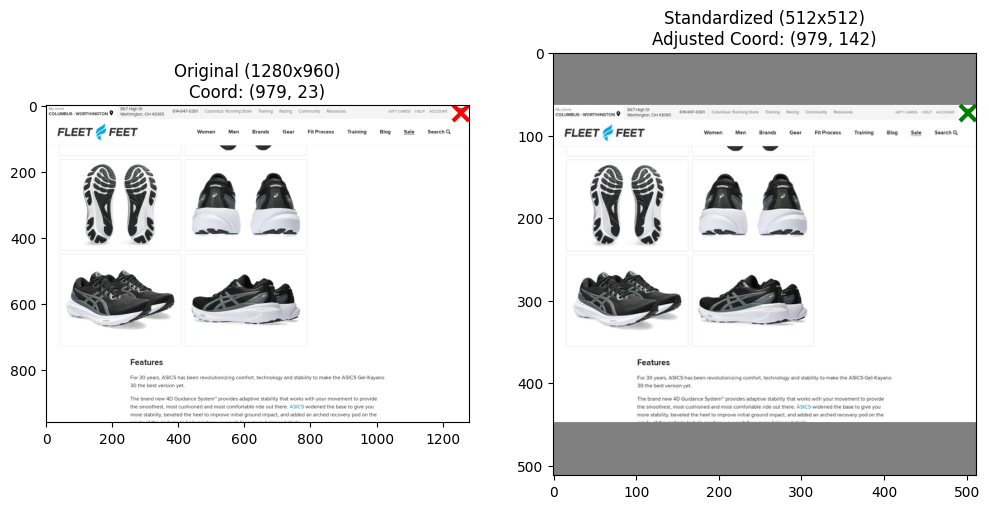

In [ ]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import json
import io
import re

TARGET_RESOLUTION = 512 # Standardize to 512x512 for training

def standardize_sample_for_training(img, original_coords_999):
    orig_w, orig_h = img.size

    # 1. Calculate scale factor to fit within TARGET_RESOLUTION
    scale = min(TARGET_RESOLUTION / orig_w, TARGET_RESOLUTION / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    # 2. Resize image
    resized_img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # 3. Create target canvas and paste resized image (padding)
    pad_x = (TARGET_RESOLUTION - new_w) // 2
    pad_y = (TARGET_RESOLUTION - new_h) // 2
    standardized_img = Image.new("RGB", (TARGET_RESOLUTION, TARGET_RESOLUTION), (128, 128, 128))
    standardized_img.paste(resized_img, (pad_x, pad_y))

    # 4. Adjust the coordinates
    adjusted_coords_999 = []
    for (nx, ny) in original_coords_999:
        # Convert normalized [0,999] to original pixels
        px = nx / 999.0 * orig_w
        py = ny / 999.0 * orig_h

        # Scale to resized pixels and add padding offset
        new_px = (px * scale) + pad_x
        new_py = (py * scale) + pad_y

        # Convert back to normalized [0,999] relative to the NEW padded canvas
        new_nx = int(round((new_px / TARGET_RESOLUTION) * 999))
        new_ny = int(round((new_py / TARGET_RESOLUTION) * 999))
        adjusted_coords_999.append((new_nx, new_ny))

    return standardized_img, adjusted_coords_999

# --- Test it on our sample ---
sample = ds[indices[0]]
img = Image.open(io.BytesIO(sample["image"]["bytes"] if isinstance(sample["image"], dict) else sample["image"])).convert("RGB")

# Extract first GPT coordinate
orig_coords = []
for turn in json.loads(sample["conversations"]):
    if turn["from"] == "gpt":
        match = re.fullmatch(r"\(([-]?\d+),\s*([-]?\d+)\)", turn["value"].strip())
        if match:
            orig_coords.append((int(match.group(1)), int(match.group(2))))
            break

standardized_img, adjusted_coords = standardize_sample_for_training(img, orig_coords)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original
axes[0].imshow(img)
orig_px = orig_coords[0][0] / 999.0 * img.width
orig_py = orig_coords[0][1] / 999.0 * img.height
axes[0].plot(orig_px, orig_py, 'rx', markersize=12, markeredgewidth=3)
axes[0].set_title(f"Original ({img.width}x{img.height})\nCoord: {orig_coords[0]}")

# Standardized
axes[1].imshow(standardized_img)
adj_px = adjusted_coords[0][0] / 999.0 * TARGET_RESOLUTION
adj_py = adjusted_coords[0][1] / 999.0 * TARGET_RESOLUTION
axes[1].plot(adj_px, adj_py, 'gx', markersize=12, markeredgewidth=3)
axes[1].set_title(f"Standardized ({TARGET_RESOLUTION}x{TARGET_RESOLUTION})\nAdjusted Coord: {adjusted_coords[0]}")

plt.show()


## 4. Model Evaluation

### 4a. Qwen2-VL-2B — Zero-Shot Baseline

Zero-shot evaluation of Qwen2-VL-2B-Instruct on the UGround grounding task.

In [1]:
# ============================================================
# Install dependencies for Qwen2-VL inference
# ============================================================
# - transformers >= 4.45.0 has native Qwen2-VL classes
# - qwen-vl-utils is the official helper for image preprocessing
# - accelerate enables device_map="auto" for memory-efficient loading
# The -q flag keeps Colab's output tidy.
!pip install -q "transformers>=4.45.0" "accelerate>=0.34.0" qwen-vl-utils

In [2]:
# ============================================================
# Load the Qwen2-VL-2B-Instruct model and processor
# ============================================================
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

# Model identifier on the Hugging Face Hub. The "Instruct" variant is
# instruction-tuned and is what we want for zero-shot prompting (vs. the
# base completion model). 2B refers to ~2 billion parameters - the smallest
# in the Qwen2-VL family, and the exact baseline our paper compares against.
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

# bfloat16 is preferred over float16 for VLMs because it has float32's
# dynamic range, avoiding overflow in attention scores. It cuts memory
# roughly in half vs float32, putting the 2B model at ~4-5 GB of GPU RAM -
# comfortably within a free-tier T4's 15 GB. Fall back to fp16 if the GPU
# (e.g. older Tesla cards) doesn't support bf16, or fp32 on CPU.
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    DTYPE = torch.bfloat16
elif torch.cuda.is_available():
    DTYPE = torch.float16
else:
    DTYPE = torch.float32  # CPU fallback - inference will be VERY slow.

# device_map="auto" lets `accelerate` shard the model across available
# devices. On a single GPU it just goes to cuda:0; on CPU-only it stays
# on CPU. This is the recommended pattern for VLMs.
DEVICE_MAP = "auto" if torch.cuda.is_available() else None

print(f"Loading {MODEL_ID}...")
print(f"  dtype     : {DTYPE}")
print(f"  device_map: {DEVICE_MAP}")
print(f"  CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU name  : {torch.cuda.get_device_name(0)}")
    print(f"  GPU mem   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Download (~4-5 GB on first run) and load weights. Subsequent runs use
# the local cache at ~/.cache/huggingface/hub.
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map=DEVICE_MAP,
)
model.eval()  # Disable dropout etc. - inference only.

# The processor wraps both the image preprocessor and the tokenizer, and
# also applies Qwen2-VL's chat template (which inserts the right
# <|vision_start|>, <|image_pad|>, <|im_start|> etc. special tokens).
processor = AutoProcessor.from_pretrained(MODEL_ID)

n_params = sum(p.numel() for p in model.parameters())
print(f"\n✓ Model loaded. Parameter count: {n_params/1e9:.2f}B")

Loading Qwen/Qwen2-VL-2B-Instruct...
  dtype     : torch.bfloat16
  device_map: auto
  CUDA avail: True
  GPU name  : Tesla T4
  GPU mem   : 15.6 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 



✓ Model loaded. Parameter count: 2.21B


In [10]:
# ============================================================
# Helper functions: prompt building, output parsing, image decoding
# ============================================================
import re
import io
from PIL import Image

# Regex that captures the FIRST (x, y) integer pair anywhere in a string.
# Matches things like "(123, 456)", "( 999,1)", "(0,0)". We allow the
# optional leading minus so that out-of-bounds negative outputs get
# parsed (and then flagged) instead of silently dropped.
_COORD_RE = re.compile(r"\(\s*(-?\d+)\s*,\s*(-?\d+)\s*\)")

def parse_coordinates(text: str):
    """
    Extract the first (x, y) coordinate pair from a model output string.

    The base Qwen2-VL model often emits verbose answers like
        "The search box is located at approximately (450, 120)."
    so we cannot assume the entire output is just coordinates - we have
    to *search* for the pattern.

    Returns (x, y) as ints, or None if no pair was found.
    """
    if not text:
        return None
    m = _COORD_RE.search(text)
    return (int(m.group(1)), int(m.group(2))) if m else None


def decode_image(img_field):
    """
    Convert the dataset's `image` field into a PIL.Image in RGB mode.

    Depending on how the parquet was written / how `datasets` decoded it,
    `image` can be one of three things, so we handle all three. Qwen2-VL
    needs 3-channel RGB input; some screenshots are RGBA or palette mode,
    so we convert.
    """
    if isinstance(img_field, Image.Image):
        img = img_field
    elif isinstance(img_field, bytes):
        img = Image.open(io.BytesIO(img_field))
    elif isinstance(img_field, dict) and "bytes" in img_field:
        img = Image.open(io.BytesIO(img_field["bytes"]))
    else:
        raise ValueError(f"Unsupported image field type: {type(img_field)}")
    return img.convert("RGB") if img.mode != "RGB" else img


# Short system prompt nudging the *base* (non-fine-tuned) model toward
# the (x,y) format the UGround dataset uses. Without it, base Qwen2-VL
# tends to either describe the location in prose or emit its own native
# bounding-box format - both would tank our format-compliance rate and
# under-represent what the model actually "knows" about UI layout.
# Set this to None for a stricter "raw" baseline (no system prompt).
SYSTEM_PROMPT = (
    "You are a GUI grounding assistant. When asked to locate a UI element "
    "in a screenshot, respond with ONLY the (x, y) coordinates of the "
    "element's center in the format (x, y), where x and y are integers in "
    "the range [0, 999] with (0, 0) at the top-left corner and (999, 999) "
    "at the bottom-right corner of the image. Do not include any other text."
)


def build_messages(image: Image.Image, human_text: str):
    """
    Build the chat-format message list Qwen2-VL expects.

    Qwen2-VL uses the OpenAI-style chat schema, but each message's
    `content` is a list of typed parts (`image`, `text`) rather than a
    single string. We strip the dataset's literal "<image>" placeholder
    from the human prompt because we're providing the image as a
    structured part - leaving it in causes Qwen2-VL to look for two
    images and error out.
    """
    cleaned_text = human_text.replace("<image>", "").strip()

    messages = []
    if SYSTEM_PROMPT:
        messages.append({"role": "system", "content": SYSTEM_PROMPT})
    messages.append({
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": cleaned_text},
        ],
    })
    return messages

In [11]:
# ============================================================
# Build the evaluation set from the loaded training data (`ds`)
# ============================================================
import json
import random

# We reuse the `ds` object loaded in the parquet cell above. If you skipped
# that section, run it first - this assertion will tell you if you did.
assert "ds" in dir(), "Run the parquet-loading cell first (it populates `ds`)."

# How many (human, gpt) Q&A pairs to evaluate. Each pair is one independent
# grounding test. At ~1-2 sec/sample on a T4:
#   100 samples  -> ~3 min   (smoke test - is everything wired up?)
#   500 samples  -> ~15 min  (reasonable confidence for a single number)
#   2000 samples -> ~1 hour  (tight CI - good for the final write-up)
N_EVAL_SAMPLES = 500

# Each row in `ds` may contain MULTIPLE Q&A pairs because web_hybrid
# screenshots have up to 25 pairs each. Limit pairs per row so a few
# screenshots don't dominate the eval and bias our metrics. Set to None
# to use every pair from every sampled row.
MAX_PAIRS_PER_ROW = 1

# Reproducible sampling: same seed -> same eval subset -> directly
# comparable metrics across runs (e.g. baseline vs fine-tuned).
random.seed(123)


def iter_eval_items(dataset, n_target, max_pairs=1):
    """
    Yield evaluation items by walking the dataset in random row order.
    Stops once `n_target` items have been yielded.

    Each item is a dict containing everything we need for both inference
    and scoring:
      - row_idx, pair_idx : provenance, useful for error inspection later
      - image             : PIL.Image, already decoded
      - width, height     : original image dims, for pixel-space metrics
      - human_text        : the prompt to feed the model
      - gt_x, gt_y        : ground-truth coordinates in [0, 999] space
    """
    # Shuffle row indices so we sample uniformly across all subfolders
    # rather than just the first N rows (which all come from one parquet
    # subfolder due to glob ordering).
    row_indices = list(range(len(dataset)))
    random.shuffle(row_indices)

    yielded = 0
    for ri in row_indices:
        if yielded >= n_target:
            return
        row = dataset[ri]

        # Defensive parse - the data audit found ~0 malformed rows but we
        # don't want one bad row to crash a 1-hour eval.
        try:
            convos = json.loads(row["conversations"])
        except (json.JSONDecodeError, TypeError):
            continue

        # Decode the image lazily so rows with no usable Q&A pairs don't
        # pay the PNG-decode cost.
        image = None
        pair_count = 0
        # Walk turn pairs: (turn[0], turn[1]) is the first Q&A,
        # (turn[2], turn[3]) is the second, and so on.
        for pi in range(0, len(convos) - 1, 2):
            if max_pairs is not None and pair_count >= max_pairs:
                break
            human_turn = convos[pi]
            gpt_turn   = convos[pi + 1]
            if human_turn.get("from") != "human" or gpt_turn.get("from") != "gpt":
                continue  # Skip if the alternation pattern is broken.

            gt = parse_coordinates(gpt_turn.get("value", ""))
            if gt is None:
                continue  # GT itself doesn't parse - rare, skip.

            if image is None:
                try:
                    image = decode_image(row["image"])
                except Exception:
                    break  # Bad image - skip the whole row.

            yield {
                "row_idx":    ri,
                "pair_idx":   pi // 2,
                "image":      image,
                "width":      row["width"],
                "height":     row["height"],
                "human_text": human_turn.get("value", ""),
                "gt_x":       gt[0],
                "gt_y":       gt[1],
            }
            pair_count += 1
            yielded += 1
            if yielded >= n_target:
                return


eval_items = list(iter_eval_items(ds, N_EVAL_SAMPLES, MAX_PAIRS_PER_ROW))
print(f"Built eval set: {len(eval_items):,} items "
      f"(from {len(set(it['row_idx'] for it in eval_items)):,} unique screenshots)")

Built eval set: 500 items (from 500 unique screenshots)


In [12]:
# ============================================================
# Run the inference loop (Qwen2-VL forward pass on every eval item)
# ============================================================
import time
from tqdm.auto import tqdm
from qwen_vl_utils import process_vision_info

# Generation hyperparameters. We want short, deterministic outputs since
# the answer is just "(x, y)". Greedy decoding (do_sample=False) gives
# reproducible results - critical for a baseline number that future
# experiments will be compared against.
MAX_NEW_TOKENS = 32      # "(999, 999)" is ~9 tokens; 32 is safe headroom.
DO_SAMPLE      = False   # Greedy - deterministic.

results = []                   # One dict per eval item, populated below.
start_time = time.time()       # For throughput reporting.

# torch.inference_mode() is slightly faster than torch.no_grad() and also
# disables view tracking. Safe here because we never backprop.
with torch.inference_mode():
    for item in tqdm(eval_items, desc="Qwen2-VL inference"):
        try:
            # 1. Build chat-formatted messages.
            messages = build_messages(item["image"], item["human_text"])

            # 2. Apply the chat template -> single string with all the
            #    right special tokens. add_generation_prompt=True appends
            #    the assistant header so the model knows it's its turn.
            prompt_text = processor.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True,
            )

            # 3. process_vision_info extracts image / video inputs from
            #    the structured messages list. It's the official Qwen
            #    helper that handles resizing to the patch grid correctly.
            image_inputs, video_inputs = process_vision_info(messages)

            # 4. Tokenize text + preprocess image into model-ready tensors.
            #    The processor returns input_ids, attention_mask,
            #    pixel_values, and image_grid_thw (shape info Qwen2-VL
            #    needs to reconstruct the 2D image layout from flat tokens).
            inputs = processor(
                text=[prompt_text],
                images=image_inputs,
                videos=video_inputs,
                return_tensors="pt",
                padding=True,
            ).to(model.device)

            # 5. Generate. The model returns the full sequence (prompt +
            #    completion), so we slice off the prompt to keep only the
            #    new generated tokens.
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=DO_SAMPLE,
            )
            new_tokens = generated_ids[:, inputs.input_ids.shape[1]:]
            output_text = processor.batch_decode(
                new_tokens,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            )[0].strip()

            # 6. Pull (x, y) out of whatever the model said.
            pred = parse_coordinates(output_text)

        except Exception as e:
            # One bad sample shouldn't kill an hour-long run. Log it as
            # an error and continue; it'll show up in metrics as a parse
            # failure (i.e. counted as wrong).
            output_text = f"[ERROR: {type(e).__name__}: {e}]"
            pred = None

        results.append({
            "row_idx":    item["row_idx"],
            "pair_idx":   item["pair_idx"],
            "width":      item["width"],
            "height":     item["height"],
            "gt_x":       item["gt_x"],
            "gt_y":       item["gt_y"],
            "raw_output": output_text,
            "pred_x":     pred[0] if pred else None,
            "pred_y":     pred[1] if pred else None,
        })

elapsed = time.time() - start_time
n = max(len(results), 1)
print(f"\n✓ Done. {len(results):,} samples in {elapsed:.1f}s "
      f"({elapsed/n:.2f}s per sample, {n/elapsed*60:.1f} samples/min)")

Qwen2-VL inference:   0%|          | 0/500 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


KeyboardInterrupt: 

In [ ]:
# ============================================================
# Compute and report performance metrics
# ============================================================
import numpy as np
import pandas as pd

# Convert results into a DataFrame for easy slicing/aggregation.
df = pd.DataFrame(results)

# ---------- Format compliance ----------
# A prediction "parsed" if we got back a (x, y) tuple at all - regardless
# of whether it's in bounds or correct. This is the most basic check of
# whether the model is even speaking the right *language* (vs. answering
# in prose or its own native bbox format).
df["parsed"] = df["pred_x"].notna() & df["pred_y"].notna()
parse_rate = df["parsed"].mean() * 100

# Of the parsed ones, are they actually within [0, 999]? Out-of-bounds
# usually means the model output absolute pixel coordinates instead of
# normalized ones - a very common failure mode for the BASE Qwen2-VL on
# UGround prompts (it has its own native coord system).
in_bounds_mask = (
    df["parsed"]
    & df["pred_x"].between(0, 999)
    & df["pred_y"].between(0, 999)
)
oob_count = (df["parsed"] & ~in_bounds_mask).sum()
oob_rate  = oob_count / max(df["parsed"].sum(), 1) * 100

# ---------- Distance errors (only on parsed-and-in-bounds preds) ----------
# Two error spaces are useful:
#   1. Normalized [0, 999]  - directly comparable across image sizes.
#   2. Original pixels       - intuitive ("the prediction was 47px off").
valid = df[in_bounds_mask].copy()
if len(valid) > 0:
    # Normalized Euclidean distance.
    valid["err_norm"] = np.sqrt(
        (valid["pred_x"] - valid["gt_x"]) ** 2
        + (valid["pred_y"] - valid["gt_y"]) ** 2
    )
    # Per-axis abs error (normalized) - shows X vs Y bias if any.
    valid["err_norm_x"] = (valid["pred_x"] - valid["gt_x"]).abs()
    valid["err_norm_y"] = (valid["pred_y"] - valid["gt_y"]).abs()

    # Pixel-space error: scale each prediction by its OWN image dims,
    # since the dataset has many different resolutions.
    pred_px_x = valid["pred_x"] / 999.0 * valid["width"]
    pred_px_y = valid["pred_y"] / 999.0 * valid["height"]
    gt_px_x   = valid["gt_x"]   / 999.0 * valid["width"]
    gt_px_y   = valid["gt_y"]   / 999.0 * valid["height"]
    valid["err_px"] = np.sqrt(
        (pred_px_x - gt_px_x) ** 2 + (pred_px_y - gt_px_y) ** 2
    )

    # Image diagonal is the natural unit for a *relative* threshold
    # (a 50-pixel error means very different things on a 1080p
    # screenshot vs a 4K one).
    img_diag = np.sqrt(valid["width"] ** 2 + valid["height"] ** 2)
    valid["err_pct_diag"] = valid["err_px"] / img_diag * 100


# ---------- Accuracy at thresholds ----------
# Standard ScreenSpot / UGround grounding metric: a prediction "hits" if
# its predicted point is within X pixels (or X% of diagonal) of the GT
# point. We report several thresholds to give the full curve, not a
# single cherry-picked number.
n_total = len(df)  # IMPORTANT: denominator is total samples - a
                   # prediction that didn't parse counts as wrong.

def acc_at(col, threshold):
    """Fraction of ALL eval samples (n_total) where col <= threshold."""
    if len(valid) == 0:
        return 0.0
    return (valid[col] <= threshold).sum() / n_total * 100


# ---------- Pretty-print the report ----------
print("=" * 72)
print(f"  Qwen2-VL-2B-Instruct - Zero-shot baseline on UGround training data")
print(f"  Eval size: {n_total:,} samples | "
      f"system prompt: {'on' if SYSTEM_PROMPT else 'off'} | greedy decoding")
print("=" * 72)

print(f"\n[Format compliance]")
print(f"  Parse rate (output looks like (x,y))      : {parse_rate:6.2f}%")
print(f"  Out-of-bounds rate (of parsed)            : {oob_rate:6.2f}%   "
      f"({int(oob_count)} samples)")
print(f"  Usable predictions (parsed + in bounds)   : {len(valid):>6} / {n_total} "
      f"({len(valid)/max(n_total,1)*100:.2f}%)")

if len(valid) > 0:
    print(f"\n[Distance error - normalized space (0-999)]")
    print(f"  Mean Euclidean error                       : {valid['err_norm'].mean():6.1f}")
    print(f"  Median Euclidean error                     : {valid['err_norm'].median():6.1f}")
    print(f"  Mean |dx|                                  : {valid['err_norm_x'].mean():6.1f}")
    print(f"  Mean |dy|                                  : {valid['err_norm_y'].mean():6.1f}")

    print(f"\n[Distance error - original pixel space]")
    print(f"  Mean pixel error                           : {valid['err_px'].mean():6.1f} px")
    print(f"  Median pixel error                         : {valid['err_px'].median():6.1f} px")
    print(f"  Mean error / image diagonal                : {valid['err_pct_diag'].mean():6.2f}%")

    print(f"\n[Accuracy @ pixel thresholds (% of all {n_total} samples)]")
    for thr in [5, 10, 25, 50, 100, 200]:
        print(f"  Acc @ {thr:>3} px                              : {acc_at('err_px', thr):6.2f}%")

    print(f"\n[Accuracy @ normalized thresholds (% of all {n_total} samples)]")
    for thr in [10, 25, 50, 100, 200]:
        print(f"  Acc @ {thr:>3} (normalized units)              : {acc_at('err_norm', thr):6.2f}%")

    print(f"\n[Accuracy @ relative thresholds (% of image diagonal)]")
    for thr in [1, 2, 5, 10]:
        print(f"  Acc @ {thr:>2}% of image diagonal              : {acc_at('err_pct_diag', thr):6.2f}%")

print("\n" + "=" * 72)

# Persist per-sample results for later analysis (e.g. compare against the
# fine-tuned Florence-2 once that's trained, error inspection, etc.).
results_path = "/content/qwen2vl_2b_baseline_results.csv"
df.to_csv(results_path, index=False)
print(f"\nFull per-sample results saved to: {results_path}")

  Qwen2-VL-2B-Instruct - Zero-shot baseline on UGround training data
  Eval size: 500 samples | system prompt: on | greedy decoding

[Format compliance]
  Parse rate (output looks like (x,y))      :  87.20%
  Out-of-bounds rate (of parsed)            :   0.00%   (0 samples)
  Usable predictions (parsed + in bounds)   :    436 / 500 (87.20%)

[Distance error - normalized space (0-999)]
  Mean Euclidean error                       :  269.3
  Median Euclidean error                     :  166.7
  Mean |dx|                                  :  181.9
  Mean |dy|                                  :  150.9

[Distance error - original pixel space]
  Mean pixel error                           :  298.4 px
  Median pixel error                         :  184.5 px
  Mean error / image diagonal                :  19.15%

[Accuracy @ pixel thresholds (% of all 500 samples)]
  Acc @   5 px                              :   0.00%
  Acc @  10 px                              :   0.60%
  Acc @  25 px          

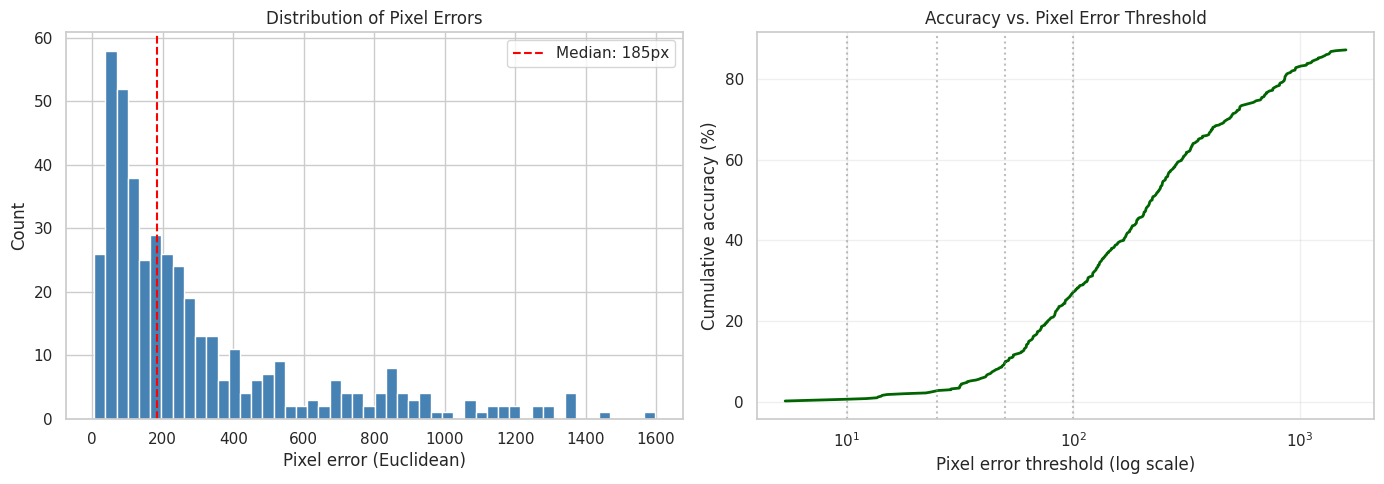

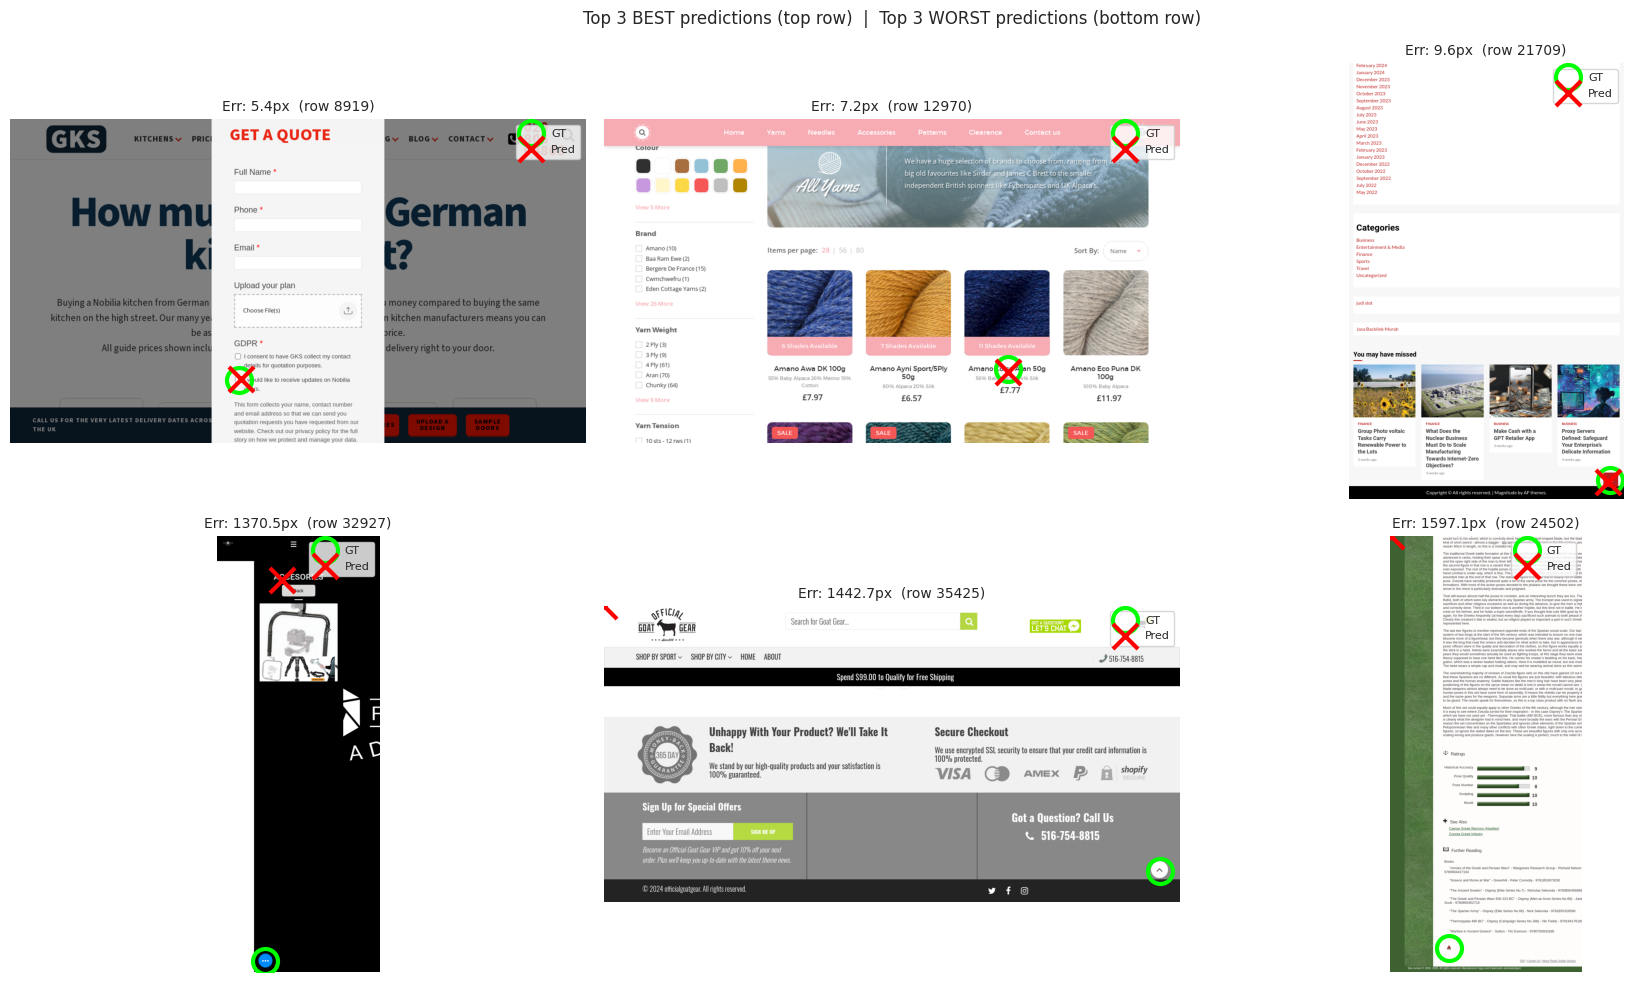


[Sample raw outputs for inspection]
------------------------------------------------------------------------
[OK ] GT=(882, 39)  raw_output='(872, 10)'
[BAD] GT=(499, 599)  raw_output='(350, 100, 950, 110)'
[OK ] GT=(561, 114)  raw_output='(500, 100)'
[OK ] GT=(338, 667)  raw_output='(242, 598)'
[OK ] GT=(148, 379)  raw_output='(333, 375)'


In [ ]:
# ============================================================
# Visualize: error distribution + qualitative best/worst examples
# ============================================================
import matplotlib.pyplot as plt

if len(valid) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of pixel errors. The shape tells us a lot:
    #   - Sharp left peak with thin tail = "mostly close, occasional miss" (good)
    #   - Flat / right-shifted distribution = "uniformly bad" (the model
    #     isn't really doing grounding, just guessing).
    axes[0].hist(valid["err_px"], bins=50, color="steelblue", edgecolor="white")
    axes[0].axvline(valid["err_px"].median(), color="red", linestyle="--",
                    label=f"Median: {valid['err_px'].median():.0f}px")
    axes[0].set_xlabel("Pixel error (Euclidean)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Pixel Errors")
    axes[0].legend()

    # Cumulative accuracy curve - one of the most useful single-plot
    # summaries of grounding quality. The steeper the early rise, the
    # more often the model nails it within a few pixels. Log x-axis
    # because errors span several orders of magnitude.
    sorted_err = np.sort(valid["err_px"].values)
    cum_acc = np.arange(1, len(sorted_err) + 1) / n_total * 100
    axes[1].plot(sorted_err, cum_acc, color="darkgreen", linewidth=2)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Pixel error threshold (log scale)")
    axes[1].set_ylabel("Cumulative accuracy (%)")
    axes[1].set_title("Accuracy vs. Pixel Error Threshold")
    axes[1].grid(True, alpha=0.3)
    # Mark common threshold values for quick visual reference.
    for thr in [10, 25, 50, 100]:
        axes[1].axvline(thr, color="gray", linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


# Show a handful of qualitative examples - 3 best + 3 worst by pixel
# error. This is invaluable for understanding what the model is doing
# well vs poorly (e.g. "always nails buttons but misses tiny icons").
if len(valid) >= 6:
    valid_sorted = valid.sort_values("err_px")
    examples = pd.concat([valid_sorted.head(3), valid_sorted.tail(3)])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, examples.iterrows()):
        # We didn't keep the PIL image in `results` (would have eaten RAM),
        # so re-decode it from `ds` using the row index we tracked.
        ds_row = ds[int(row["row_idx"])]
        img = decode_image(ds_row["image"])
        ax.imshow(img)

        # Convert normalized [0, 999] coords back to pixels for plotting
        # on top of the original-resolution image.
        gt_px_x = row["gt_x"]   / 999.0 * row["width"]
        gt_px_y = row["gt_y"]   / 999.0 * row["height"]
        pr_px_x = row["pred_x"] / 999.0 * row["width"]
        pr_px_y = row["pred_y"] / 999.0 * row["height"]

        # Open green circle = ground truth; red X = prediction.
        ax.plot(gt_px_x, gt_px_y, "o",
                markersize=18, markerfacecolor="none",
                markeredgecolor="lime", markeredgewidth=3, label="GT")
        ax.plot(pr_px_x, pr_px_y, "x",
                markersize=18, markeredgecolor="red", markeredgewidth=3,
                label="Pred")
        ax.set_title(f"Err: {row['err_px']:.1f}px  (row {int(row['row_idx'])})",
                     fontsize=10)
        ax.legend(loc="upper right", fontsize=8)
        ax.axis("off")

    plt.suptitle("Top 3 BEST predictions (top row)  |  "
                 "Top 3 WORST predictions (bottom row)",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


# Print a few raw model outputs so we can see HOW the model is failing
# when it fails - especially useful for diagnosing format issues.
print("\n[Sample raw outputs for inspection]")
print("-" * 72)
for _, row in df.sample(min(5, len(df)), random_state=0).iterrows():
    in_bounds = (pd.notna(row["pred_x"])
                 and 0 <= row["pred_x"] <= 999
                 and 0 <= row["pred_y"] <= 999)
    status = "OK " if in_bounds else "BAD"
    print(f"[{status}] GT=({row['gt_x']}, {row['gt_y']})  "
          f"raw_output={row['raw_output']!r}")

### 4b. Florence-2 (0.77B) — Fine-Tuning

This section covers our Florence-2 pipeline:
1. Model selection justification & architecture overview
2. Data preprocessing for Florence-2
3. Dataset class, collator, and DataLoader
4. Zero-shot inference demo
5. Evaluation: L2, tolerance accuracy, GT-in-predicted-box
6. Fine-tuning setup (freeze vision encoder, training loop)
7. Results visualisation & interpretation
8. Architecture/resource comparison vs. Qwen2-VL (2B)

## B1. Model Overview & Architecture Justification

Florence-2-large (0.77B) is a unified vision-language model from Microsoft Research trained on the FLD-5B dataset.  
It uses a **sequence-to-sequence** architecture, which makes it straightforward to fine-tune for tasks that require text output conditioned on an image.

### Architecture summary

| Component | Details |
|---|---|
| Image Encoder | DaViT (Dual Attention Vision Transformer) |
| Language Head | BART-style encoder–decoder |
| Total Parameters | **0.77 B** (Florence-2-large) |
| Native Coord Format | `<loc_XYZ>` tokens, range 0–999 |
| Grounding Task | `<REFERRING_EXPRESSION_COMPREHENSION>` → bounding box |

### Why Florence-2 for UI grounding?

- **Native 0–999 coordinate tokens** — UGround normalises all coordinates to [0, 999], exactly matching Florence-2's `<loc_XYZ>` vocabulary.
- **Compact size** — at 0.77 B it is ~2.6× smaller than Qwen2-VL (2B), enabling faster training iterations with less GPU memory.
- **Strong zero-shot REC baseline** — `<REFERRING_EXPRESSION_COMPREHENSION>` (REC) allows out-of-the-box referring expression grounding without any fine-tuning.
- **LoRA-friendly** — standard transformer decoder makes low-rank adaptation straightforward.

In [16]:
from transformers import AutoProcessor, AutoModelForCausalLM
import torch

# multimodalart/Florence-2-large-no-flash-attn is a community re-upload of
# microsoft/Florence-2-base-ft with flash_attn removed from imports — no patching needed.
FLORENCE_MODEL_ID = "multimodalart/Florence-2-large-no-flash-attn"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Loading {FLORENCE_MODEL_ID} on {DEVICE} ...")

florence_processor = AutoProcessor.from_pretrained(
    FLORENCE_MODEL_ID,
    trust_remote_code=True,
)
florence_model = AutoModelForCausalLM.from_pretrained(
    FLORENCE_MODEL_ID,
    torch_dtype=torch.float16 if DEVICE.type == "cuda" else torch.float32,
    trust_remote_code=True,
).to(DEVICE)

florence_model.eval()
total_params = sum(p.numel() for p in florence_model.parameters()) / 1e6
print(f"Loaded. Parameters: {total_params:.1f} M")

Loading microsoft/Florence-2-base-ft on cuda ...


<unknown>:515: SyntaxWarning: invalid escape sequence '\d'
You are using a model of type florence2 to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


AttributeError: TokenizersBackend has no attribute additional_special_tokens

## B2. Data Preprocessing for Florence-2

Florence-2's `<REFERRING_EXPRESSION_COMPREHENSION>` (REC) task expects:

| I/O | Format |
|---|---|
| **Input** | `<REFERRING_EXPRESSION_COMPREHENSION> {referring expression}` |
| **Output** | `{label}<loc_X1><loc_Y1><loc_X2><loc_Y2>` (bounding box, 0–999) |

UGround provides **point** annotations (single `(x, y)` in [0, 999]).  Our pipeline:

1. Extract the referring expression (human turn) and GT point (GPT turn).
2. Feed the image + expression to Florence-2 → get predicted bounding box.
3. Compute the **center** of the predicted box as the predicted point.
4. Evaluate against the GT point using our metrics (see §B4).

In [50]:
import re, json, io
from PIL import Image
from torch.utils.data import Dataset


def extract_uground_sample(row):
    """Parse a UGround dataset row into (image, referring_expr, gt_point).
    Handles conversations as a JSON string OR an already-parsed list.
    Image may be raw bytes or a dict with a 'bytes' key.
    """
    # --- Image ---
    img_data = row.get("image")
    if img_data is None:
        return None
    try:
        if isinstance(img_data, bytes):
            img = Image.open(io.BytesIO(img_data)).convert("RGB")
        elif isinstance(img_data, dict) and "bytes" in img_data:
            img = Image.open(io.BytesIO(img_data["bytes"])).convert("RGB")
        else:
            img = img_data.convert("RGB") if hasattr(img_data, "convert") else None
        if img is None:
            return None
    except Exception:
        return None

    # --- Conversations: string or already-parsed list ---
    convos_raw = row.get("conversations")
    try:
        if isinstance(convos_raw, str):
            convos = json.loads(convos_raw)
        elif isinstance(convos_raw, list):
            convos = convos_raw
        else:
            return None
    except (json.JSONDecodeError, TypeError):
        return None

    referring_expr, gt_point = None, None
    for turn in convos:
        if turn.get("from") == "human" and referring_expr is None:
            referring_expr = re.sub(r"<image>", "", turn.get("value", "")).strip()
        if turn.get("from") == "gpt" and gt_point is None:
            m = re.fullmatch(r"\(\s*(\d+)\s*,\s*(\d+)\s*\)", turn.get("value", "").strip())
            if m:
                gt_point = (int(m.group(1)), int(m.group(2)))

    if not referring_expr or gt_point is None:
        return None

    return {
        "image": img,
        "referring_expression": referring_expr,
        "gt_point": gt_point,
        "width": row.get("width") or img.width,
        "height": row.get("height") or img.height,
    }


class FlorenceSampleDataset(Dataset):
    """Wraps the pre-parsed florence_samples list for fine-tuning."""
    TASK = "<REFERRING_EXPRESSION_COMPREHENSION>"

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p = self.samples[idx]
        question = self.TASK + " " + p["referring_expression"]
        gx, gy = p["gt_point"]
        margin = 25
        x1, y1 = max(0, gx - margin), max(0, gy - margin)
        x2, y2 = min(999, gx + margin), min(999, gy + margin)
        answer = f"element<loc_{x1}><loc_{y1}><loc_{x2}><loc_{y2}>"
        return question, answer, p["image"]

In [51]:
# ── Data bridge ───────────────────────────────────────────────────────────────
# Priority:
#   1. Google Drive parquet files (persistent, fastest after first extraction)
#   2. Google Drive dataset already loaded this session (ds + indices)
#   3. Fresh HuggingFace streaming sample (no Drive needed, requires HF token)

FLORENCE_N_SAMPLES = 20

florence_samples = []

# ── Path 1: Drive parquet files exist → stream a small sample directly ────────
_drive_extract = "/content/drive/MyDrive/Too CUA for School/MS3/jonathanliuground-v1-subsample"
if not florence_samples and os.path.isdir(_drive_extract):
    import glob as _glob
    _pq_files = _glob.glob(f"{_drive_extract}/**/*.parquet", recursive=True)
    if _pq_files:
        print(f"Source: Google Drive parquet files ({len(_pq_files)} files) — streaming sample...")
        from datasets import load_dataset as _ld
        _drive_stream = _ld(
            "parquet",
            data_files={"train": f"{_drive_extract}/**/*.parquet"},
            split="train",
            streaming=True,
        )
        for i, row in enumerate(_drive_stream):
            if len(florence_samples) >= FLORENCE_N_SAMPLES:
                break
            parsed = extract_uground_sample(row)
            if parsed:
                parsed['source_idx'] = i
                florence_samples.append(parsed)

# ── Path 2: Full ds already loaded this session ───────────────────────────────
if not florence_samples and 'ds' in dir() and 'indices' in dir() and len(indices) > 0:
    print("Source: loaded dataset (ds).")
    for idx in indices[:FLORENCE_N_SAMPLES]:
        parsed = extract_uground_sample(ds[idx])
        if parsed:
            parsed['source_idx'] = idx
            florence_samples.append(parsed)

# ── Path 3: Fresh HuggingFace stream (needs HF token) ────────────────────────
if not florence_samples:
    print(f"Source: HuggingFace stream (fetching {FLORENCE_N_SAMPLES} samples)...")
    from datasets import load_dataset as _ld
    _hf_stream = _ld(
        "osunlp/UGround-V1-Data", split="train",
        streaming=True, trust_remote_code=True,
    )
    for i, row in enumerate(_hf_stream):
        if len(florence_samples) >= FLORENCE_N_SAMPLES:
            break
        parsed = extract_uground_sample(row)
        if parsed:
            parsed['source_idx'] = i
            florence_samples.append(parsed)
        if (i + 1) % 50 == 0:
            print(f"  Scanned {i+1} rows, found {len(florence_samples)} ...")

print(f"\nReady: {len(florence_samples)} samples.")
for p in florence_samples[:2]:
    print(f"  RE : {p['referring_expression'][:70]}")
    print(f"  GT : {p['gt_point']}  |  {p['width']}x{p['height']}")
    print()

Source: Google Drive parquet files (14 files) — streaming sample...

Ready: 20 samples.
  RE : Your task is to help the user identify the precise coordinates (x, y) 
  GT : (210, 376)  |  1434x806

  RE : Your task is to help the user identify the precise coordinates (x, y) 
  GT : (335, 545)  |  1436x807



In [52]:
from torch.utils.data import DataLoader, Dataset


class FlorenceSampleDataset(Dataset):
    """Wraps the pre-parsed florence_samples list for fine-tuning."""
    TASK = "<REFERRING_EXPRESSION_COMPREHENSION>"

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p = self.samples[idx]
        question = self.TASK + " " + p["referring_expression"]
        # Pseudo-box from GT point (±25 in 0-999 space) as training target
        gx, gy = p["gt_point"]
        margin = 25
        x1, y1 = max(0, gx - margin), max(0, gy - margin)
        x2, y2 = min(999, gx + margin), min(999, gy + margin)
        answer = f"element<loc_{x1}><loc_{y1}><loc_{x2}><loc_{y2}>"
        return question, answer, p["image"]


def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if not batch:
        return None
    questions, answers, images = zip(*batch)
    inputs = florence_processor(
        text=list(questions), images=list(images),
        return_tensors="pt", padding=True,
    ).to(DEVICE)
    return inputs, list(answers)


# Build train / val splits from florence_samples
if florence_samples:
    split = int(0.8 * len(florence_samples))
    train_dataset = FlorenceSampleDataset(florence_samples[:split])
    val_dataset   = FlorenceSampleDataset(florence_samples[split:])

    BATCH_SIZE = 2
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              collate_fn=collate_fn, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                              collate_fn=collate_fn)

    print(f"Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
    print(f"Val  : {len(val_dataset)} samples ({len(val_loader)} batches)")
else:
    print("Run the data-bridge cell above first.")

Train: 16 samples (8 batches)
Val  : 4 samples (2 batches)


## B3. Zero-Shot Inference

Before any fine-tuning, we run Florence-2 in **zero-shot** mode using the  
`<REFERRING_EXPRESSION_COMPREHENSION>` task to establish a baseline.  

This mirrors the approach from the reference fine-tuning notebook (Cell 9).

In [53]:
import time

TASK = "<REFERRING_EXPRESSION_COMPREHENSION>"


def run_example(task_prompt, text_input, image):
    """Run Florence-2 on a single image + text input. Returns parsed output dict."""
    prompt = task_prompt + " " + text_input
    if image.mode != "RGB":
        image = image.convert("RGB")

    inputs = florence_processor(text=prompt, images=image, return_tensors="pt").to(DEVICE)
    generated_ids = florence_model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"].to(
            torch.float16 if DEVICE.type == "cuda" else torch.float32
        ),
        max_new_tokens=64,
        do_sample=False,
        num_beams=3,
    )
    generated_text = florence_processor.batch_decode(
        generated_ids, skip_special_tokens=False
    )[0]
    parsed = florence_processor.post_process_generation(
        generated_text, task=task_prompt,
        image_size=(image.width, image.height),
    )
    return parsed


# --- Run on florence_samples ---
print(f"Zero-shot inference on {len(florence_samples)} samples ...")

results = []
t0 = time.time()
for sample_data in florence_samples:
    parsed = run_example(TASK, sample_data["referring_expression"], sample_data["image"])

    pred_box = None
    if TASK in parsed:
        boxes = parsed[TASK].get("bboxes", [])
        if boxes:
            pred_box = boxes[0]   # [x1, y1, x2, y2] in original pixel coords

    results.append({
        "source_idx": sample_data["source_idx"],
        "referring_expression": sample_data["referring_expression"],
        "gt_point": sample_data["gt_point"],        # (x, y) in [0, 999]
        "image_size": (sample_data["width"], sample_data["height"]),
        "image": sample_data["image"],              # stored for visualisation
        "pred_box_pixels": pred_box,
    })

elapsed = time.time() - t0
n_pred = sum(1 for r in results if r["pred_box_pixels"] is not None)
print(f"Done. {len(results)} samples | {n_pred} with predictions | {elapsed:.1f}s total")

Zero-shot inference on 20 samples ...


NameError: name 'florence_processor' is not defined

## B4. Evaluation Metrics & Loss Functions

Based on TF feedback, we move beyond simple L2 distance.  
**"Being within the region"** of the target element is functionally correct — a click anywhere on a button is a successful interaction.

### Metrics

| Metric | Definition | Rationale |
|---|---|---|
| **L2 Distance (px)** | Euclidean distance between predicted center and GT point | Simplest baseline; fully differentiable |
| **Normalised L2** | L2 / image diagonal | Resolution-invariant; comparable across screen sizes |
| **Tolerance Acc @ k%** | `1[L2 < k% × diagonal]` (k = 5, 10, 25) | Standard in grounding literature; captures "close enough" |
| **GT-in-predicted-box** | `1[GT_x ∈ [x̂₁,x̂₂] and GT_y ∈ [ŷ₁,ŷ₂]]` | Florence-2-specific: did the predicted box cover the GT point? |

> **Why not just L2?**  A prediction 30 px from center on a 200×50 button is still functionally correct.  
> Tolerance accuracy and GT-in-box capture this — penalising catastrophic misses while accepting near-misses.

In [ ]:
import numpy as np
import pandas as pd

TOLERANCES = [0.05, 0.10, 0.25]   # fractions of image diagonal


def compute_metrics(results):
    rows = []
    for r in results:
        gt_nx, gt_ny = r["gt_point"]
        orig_w, orig_h = r["image_size"]

        gt_px = gt_nx / 999.0 * orig_w
        gt_py = gt_ny / 999.0 * orig_h
        diag  = (orig_w**2 + orig_h**2) ** 0.5

        if r["pred_box_pixels"] is None:
            rows.append({"idx": r["idx"], "l2_pixels": np.nan, "l2_norm": np.nan,
                         **{f"acc@{int(t*100)}pct": np.nan for t in TOLERANCES},
                         "gt_in_box": np.nan, "no_pred": True})
            continue

        x1, y1, x2, y2 = r["pred_box_pixels"]
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

        l2      = ((cx - gt_px)**2 + (cy - gt_py)**2) ** 0.5
        l2_norm = l2 / diag

        rows.append({
            "idx": r["idx"],
            "l2_pixels": l2,
            "l2_norm": l2_norm,
            **{f"acc@{int(t*100)}pct": int(l2 < t * diag) for t in TOLERANCES},
            "gt_in_box": int(x1 <= gt_px <= x2 and y1 <= gt_py <= y2),
            "no_pred": False,
        })
    return rows


metrics = compute_metrics(results)
df = pd.DataFrame(metrics)

print("=== Florence-2 Zero-Shot Grounding — Summary ===")
print(f"Samples evaluated : {len(df)}")
print(f"No prediction     : {int(df['no_pred'].sum())}")

df_v = df[~df["no_pred"]]
if len(df_v):
    print(f"\nMean L2 (pixels)  : {df_v['l2_pixels'].mean():.1f}")
    print(f"Mean Normalised L2: {df_v['l2_norm'].mean():.3f}")
    print(f"Acc @ 5%  diag    : {df_v['acc@5pct'].mean()*100:.1f}%")
    print(f"Acc @ 10% diag    : {df_v['acc@10pct'].mean()*100:.1f}%")
    print(f"Acc @ 25% diag    : {df_v['acc@25pct'].mean()*100:.1f}%")
    print(f"GT-in-predicted-box: {df_v['gt_in_box'].mean()*100:.1f}%")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def visualise_predictions(results, metrics, n_show=4):
    valid = [(r, m) for r, m in zip(results, metrics) if not m["no_pred"]][:n_show]
    if not valid:
        print("No valid predictions to visualise (all returned empty boxes).")
        print("This is expected for zero-shot Florence-2 on unseen GUI data — motivates fine-tuning.")
        return

    fig, axes = plt.subplots(1, len(valid), figsize=(5 * len(valid), 5))
    if len(valid) == 1:
        axes = [axes]

    for ax, (r, m) in zip(axes, valid):
        img = r["image"]
        orig_w, orig_h = r["image_size"]

        gt_px = r["gt_point"][0] / 999.0 * orig_w
        gt_py = r["gt_point"][1] / 999.0 * orig_h
        x1, y1, x2, y2 = r["pred_box_pixels"]
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

        ax.imshow(img)
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            lw=2, edgecolor="dodgerblue", facecolor="none", label="Pred box",
        )
        ax.add_patch(rect)
        ax.scatter([cx],    [cy],    c="dodgerblue", s=80,  zorder=5, label="Pred center")
        ax.scatter([gt_px], [gt_py], c="red", marker="*", s=200, zorder=6, label="GT point")

        in_box = bool(m["gt_in_box"])
        ax.set_title(
            f"L2={m['l2_pixels']:.0f}px | GT-in-box={'✓' if in_box else '✗'}",
            fontsize=10,
        )
        ax.axis("off")
        ax.legend(fontsize=7, loc="upper right")

    plt.suptitle("Florence-2 Zero-Shot: Predicted Box vs GT Point", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("florence2_zero_shot.png", dpi=100, bbox_inches="tight")
    plt.show()


visualise_predictions(results, metrics)

## B5. Fine-Tuning Setup

Following the reference notebook approach, we:
1. **Freeze the vision tower** (DaViT encoder) — reduces trainable parameters and GPU memory; the authors report improvement when unfreezing, but at higher resource cost.
2. Train only the language decoder (+ projection layers) using AdamW with a linear LR schedule.
3. Labels are the tokenized Florence-2 target strings (`element<loc_X1><loc_Y1><loc_X2><loc_Y2>`).

In [ ]:
import os
from tqdm import tqdm
import torch.optim as optim
from transformers import get_scheduler


# ── 1. Freeze the image encoder ───────────────────────────────────────────────
for param in florence_model.vision_tower.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in florence_model.parameters() if p.requires_grad) / 1e6
frozen    = sum(p.numel() for p in florence_model.parameters() if not p.requires_grad) / 1e6
print(f"Trainable params : {trainable:.1f} M")
print(f"Frozen params    : {frozen:.1f} M")


# ── 2. Training loop ──────────────────────────────────────────────────────────
def train_model(train_loader, val_loader, model, processor, epochs=1, lr=1e-6):
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=lr
    )
    num_training_steps = epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", optimizer=optimizer,
        num_warmup_steps=0, num_training_steps=num_training_steps,
    )

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]"):
            if batch is None:
                continue
            inputs, answers = batch
            labels = processor.tokenizer(
                text=answers, return_tensors="pt",
                padding=True, return_token_type_ids=False,
            ).input_ids.to(DEVICE)

            outputs = model(
                input_ids=inputs["input_ids"],
                pixel_values=inputs["pixel_values"].to(
                    torch.float16 if DEVICE.type == "cuda" else torch.float32
                ),
                labels=labels,
            )
            outputs.loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            train_loss += outputs.loss.item()

        avg_train = train_loss / max(len(train_loader), 1)
        print(f"  Avg train loss: {avg_train:.4f}")

        # --- Validate ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]"):
                if batch is None:
                    continue
                inputs, answers = batch
                labels = processor.tokenizer(
                    text=answers, return_tensors="pt",
                    padding=True, return_token_type_ids=False,
                ).input_ids.to(DEVICE)
                outputs = model(
                    input_ids=inputs["input_ids"],
                    pixel_values=inputs["pixel_values"].to(
                        torch.float16 if DEVICE.type == "cuda" else torch.float32
                    ),
                    labels=labels,
                )
                val_loss += outputs.loss.item()

        avg_val = val_loss / max(len(val_loader), 1)
        print(f"  Avg val loss  : {avg_val:.4f}")

        ckpt_dir = f"./florence2_checkpoints/epoch_{epoch+1}"
        os.makedirs(ckpt_dir, exist_ok=True)
        model.save_pretrained(ckpt_dir)
        processor.save_pretrained(ckpt_dir)
        print(f"  Checkpoint saved → {ckpt_dir}")


# Un-comment to run fine-tuning:
# train_model(train_loader, val_loader, florence_model, florence_processor, epochs=2)

## B6. Architecture & Resource Comparison: Florence-2 vs. Qwen2-VL

| | **Florence-2-large** | **Qwen2-VL-2B** |
|---|---|---|
| Parameters | **0.77 B** | 2 B |
| Image Encoder | DaViT (Dual Attention ViT) | ViT with RoPE-2D |
| Language Head | BART encoder–decoder | Qwen2 decoder-only |
| Native Coord Format | `<loc_XYZ>` tokens (0–999) | `(x, y)` point (0–999) |
| Native Grounding Output | Bounding box | Point |
| GPU Memory (fp16) | ~3–4 GB | ~6–8 GB |
| Relative Inference Speed | ~2.6× faster | Baseline |

**Key observation**: Florence-2 natively outputs *boxes*, while UGround labels are *points*.  
Qwen2-VL is pre-trained to output points directly, which is a closer fit.  
This makes the Florence-2 vs. Qwen2-VL comparison meaningful — Florence-2 may close the gap with fine-tuning.

## B7. Baseline Analysis & Future Directions

### Strengths
- Florence-2's `<loc_XYZ>` tokens (0–999) align with UGround's normalisation — no conversion needed.
- 0.77 B parameters → faster iteration, lower GPU cost, easier ablation studies.
- Standard encoder–decoder architecture makes LoRA adaptation straightforward.

### Weaknesses
- Outputs **boxes**, not points — center-extraction adds a post-processing step and error source.
- Zero-shot REC may be biased towards natural-image objects rather than GUI elements.
- Smaller capacity may limit performance on complex, multi-element screens.

### Future Directions
- **LoRA fine-tuning on 3.4% of UGround**: low-rank adaptation of the decoder to output tight element boxes.
- **Alternative loss functions for fine-tuning**:
  - *L2 loss on predicted center vs GT point* — directly optimises point prediction.
  - *Soft-IoU / GIoU* — rewards box overlap with a pseudo-box around the GT point.
  - *Tolerance-based reward signal* — RLHF-style training with "within-region" as reward.
- **Unfreeze vision tower** in later epochs once the decoder is stable (as noted in the reference notebook).
- **Head-to-head comparison with Qwen2-VL (Tim's setup)** after equal training-step budget.